<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/ICG_subcomplexes/RBICG_full_code_v3_(BL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This version 3 contains only the patients whose icg was recorded in baseline state (task BL)

###Data download

In [2]:
!mkdir /content/RawData/
!wget -q https://zenodo.org/records/4725433/files/01_RawData.zip?download=1 -O /content/RawData/01_RawData.zip
!unzip -qo /content/RawData/01_RawData.zip -d /content/RawData/

!mkdir /content/FilteredData/
!wget -q https://zenodo.org/records/4725433/files/02_FilteredData.zip?download=1 -O /content/FilteredData/02_FilteredData.zip
!unzip -qo /content//FilteredData/02_FilteredData.zip -d /content//FilteredData/

!mkdir /content/Annotations/
!wget -q https://zenodo.org/records/4725433/files/03_ExpertAnnotations.zip?download=1 -O /content/Annotations/02_FilteredData.zip
!unzip -qo /content/Annotations/02_FilteredData.zip -d /content/Annotations/

mkdir: cannot create directory ‘/content/RawData/’: File exists
mkdir: cannot create directory ‘/content/FilteredData/’: File exists
mkdir: cannot create directory ‘/content/Annotations/’: File exists


###Libraries

In [3]:
!pip install neurokit2

In [4]:
!pip install pyclustering

In [5]:
!pip install tslearn

In [6]:
!pip install kneed

In [7]:
# Librerías estándar
import os
import random
from itertools import combinations

# Librerías científicas
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.signal as signal
from scipy.signal import (
    welch,
    butter,
    filtfilt,
    find_peaks,
    savgol_filter,
    argrelextrema
)
from scipy.ndimage import gaussian_filter1d
from scipy.stats import skew, kurtosis
from scipy.spatial.distance import pdist

# Visualización
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.model_selection import train_test_split

# Clustering y DTW
from pyclustering.cluster.kmedoids import kmedoids
from tslearn.metrics import cdist_dtw

# NeuroKit
import neurokit2 as nk


###General algorithm

In [ ]:
# Parámetros
fs = 250
pre_r = int(0.15 * fs)
post_r = int(0.6 * fs)
conditions = ['BL']
num_patients = 24

# Lista para almacenar segmentos
all_segments = []

for patient_id in range(1, num_patients + 1):
    for condition in conditions:
        try:
            # Rutas
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{patient_id}_task_{condition}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{patient_id}_task_{condition}.mat'

            # Comprobar si los archivos existen
            if not os.path.exists(path_filtered):
                print(f"Archivo filtrado NO encontrado: {path_filtered}")
                continue
            if not os.path.exists(path_annotation):
                print(f"Archivo de anotaciones NO encontrado (pero no crítico): {path_annotation}")
                #Este paso se realiza para que CW con los pacientes 5 y 16 sea igual de robusto.

            # Cargar ECG y ICG filtrados
            data_filtered = sio.loadmat(path_filtered)
            ecg_filtered = data_filtered['ECG'].flatten().astype(np.float64)
            icg_filtered = data_filtered['ICG'].flatten().astype(np.float64)

            # Cargar anotaciones si existen (por si se quieren usar más adelante)
            if os.path.exists(path_annotation):
                annotation = sio.loadmat(path_annotation)
                annotations = annotation['annotPoints']
                B, C, X, O = annotations[:, 0], annotations[:, 1], annotations[:, 2], annotations[:, 3]

            # Procesar ECG para encontrar picos R
            ecg_signals, info = nk.ecg_process(ecg_filtered, sampling_rate=fs)
            r_peaks = info["ECG_R_Peaks"]

            # Segmentación de ICG alrededor de picos R
            for i, r_peak in enumerate(r_peaks):
                start_idx = r_peak - pre_r
                end_idx = r_peak + post_r
                if start_idx >= 0 and end_idx < len(icg_filtered):
                    segment = icg_filtered[start_idx:end_idx]
                    # Normalizar en amplitud (valor absoluto máximo igual a 1)
                    max_amplitude = np.max(np.abs(segment))
                    if max_amplitude == 0:  # Evitar división por cero
                        max_amplitude = 1
                    segment_norm = segment / max_amplitude

                    all_segments.append({
                        'Segment': segment_norm,
                        'PatientID': patient_id,
                        'BeatNumber': i + 1,
                        'Condition': condition
                    })

        except Exception as e:
            print(f"Error con paciente {patient_id}, condición {condition}: {e}")

# Crear DataFrame
df_segments = pd.DataFrame(all_segments)

#Para poder abrirlo en excel y ver qué forma tiene.
df_segments.to_csv("icg_segments_all.csv", index=False)


Archivo de anotaciones NO encontrado (pero no crítico): /content/Annotations/Annotat_Subject_5_task_CW.mat
Archivo de anotaciones NO encontrado (pero no crítico): /content/Annotations/Annotat_Subject_16_task_CW.mat


We want to plot ICG spectra because we observe baseline fluctutations

/usr/local/lib/python3.11/dist-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 187, using nperseg = 187
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


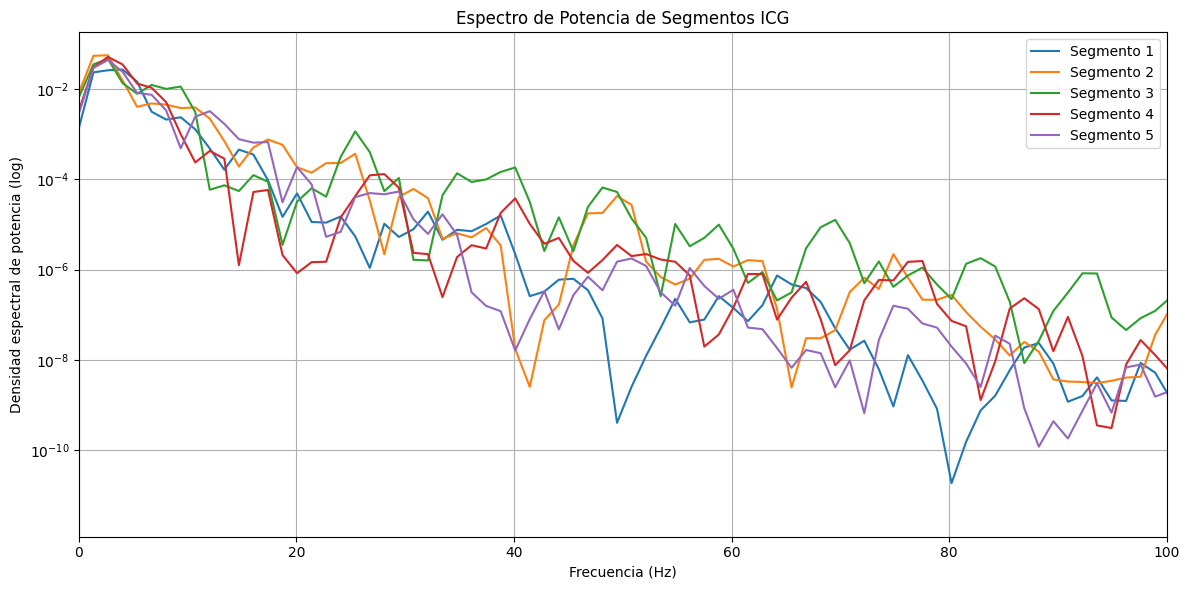

In [ ]:
def plot_icg_spectra(df, fs=250, n_segments=5, freq_max=100):
    """
    Selecciona segmentos aleatorios y muestra su espectro de potencia.

    Args:
        df (pd.DataFrame): DataFrame con columna 'Segment'.
        fs (int): Frecuencia de muestreo.
        n_segments (int): Número de segmentos a mostrar.
        freq_max (float): Máxima frecuencia a mostrar en Hz.
    """
    # Seleccionar filas aleatorias
    sampled_segments = df.sample(n=n_segments, random_state=42)

    plt.figure(figsize=(12, 6))
    for i, row in enumerate(sampled_segments.itertuples()):
        segment = row.Segment
        # Asegurar que es array de tipo float
        if isinstance(segment, list):  # Por si CSV lo carga como lista
            segment = np.array(segment, dtype=np.float64)
        # Calcular espectro con Welch
        freqs, psd = welch(segment, fs=fs, nperseg=256)
        plt.semilogy(freqs, psd, label=f'Segmento {i+1}')

    plt.title('Espectro de Potencia de Segmentos ICG')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Densidad espectral de potencia (log)')
    plt.xlim(0, freq_max)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Llamar a la función
plot_icg_spectra(df_segments, fs=fs, n_segments=5)

Random segments were selected, and their power spectrum showed very high-frequency components that may correspond to noise rather than useful information from the ICG. For this reason, a band-pass filter from 0.5 to 20 Hz was applied to the already filtered signal, allowing only the desired frequency range to be retained.

In [8]:
# Parámetros
fs = 250
lowcut = 0.5
highcut = 20
pre_r = int(0.15 * fs)
post_r = int(0.6 * fs)
conditions = ['BL']
num_patients = 24

# Función para filtro pasa banda Butterworth
def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

# Lista para almacenar segmentos
all_segments = []

for patient_id in range(1, num_patients + 1):
    for condition in conditions:
        try:
            # Rutas
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{patient_id}_task_{condition}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{patient_id}_task_{condition}.mat'

            if not os.path.exists(path_filtered):
                print(f"Archivo filtrado NO encontrado: {path_filtered}")
                continue
            if not os.path.exists(path_annotation):
                print(f"Archivo de anotaciones NO encontrado (pero no crítico): {path_annotation}")

            # Cargar ECG e ICG
            data_filtered = sio.loadmat(path_filtered)
            ecg_filtered = data_filtered['ECG'].flatten().astype(np.float64)
            icg_filtered = data_filtered['ICG'].flatten().astype(np.float64)

            # Cargar anotaciones si existen
            if os.path.exists(path_annotation):
                annotation = sio.loadmat(path_annotation)
                annotations = annotation['annotPoints']
                B, C, X, O = annotations[:, 0], annotations[:, 1], annotations[:, 2], annotations[:, 3]

            # Detección de picos R
            ecg_signals, info = nk.ecg_process(ecg_filtered, sampling_rate=fs)
            r_peaks = info["ECG_R_Peaks"]

            # Segmentación de ICG
            for i, r_peak in enumerate(r_peaks):
                start_idx = r_peak - pre_r
                end_idx = r_peak + post_r
                if start_idx >= 0 and end_idx < len(icg_filtered):
                    segment = icg_filtered[start_idx:end_idx]

                    # 🟡 Aplicar filtro pasa banda
                    segment_filtered = bandpass_filter(segment, fs, lowcut, highcut)

                    # 🔵 Normalizar (amplitud máxima = 1)
                    max_amplitude = np.max(np.abs(segment_filtered))
                    if max_amplitude == 0:
                        max_amplitude = 1
                    segment_norm = segment_filtered / max_amplitude

                    all_segments.append({
                        'Segment': segment_norm,
                        'PatientID': patient_id,
                        'BeatNumber': i + 1,
                        'Condition': condition
                    })

        except Exception as e:
            print(f"Error con paciente {patient_id}, condición {condition}: {e}")

# Crear DataFrame
df_segments = pd.DataFrame(all_segments)
df_segments.to_csv("icg_segments_all.csv", index=False)


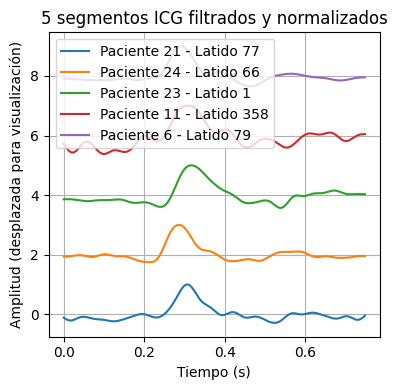

In [9]:
def plot_random_icg_segments(df, fs=250, num_signals=5):
    """
    Muestra num_signals segmentos ICG aleatorios del DataFrame.

    Parámetros:
    - df: DataFrame con columna 'Segment' que contiene arrays de segmentos.
    - fs: Frecuencia de muestreo (Hz).
    - num_signals: Número de señales a graficar.
    """
    selected = df.sample(n=num_signals, random_state=42)  # Mismo resultado si se ejecuta varias veces
    time = np.linspace(0, len(selected.iloc[0]['Segment']) / fs, len(selected.iloc[0]['Segment']))

    plt.figure(figsize=(4, 4))
    for i, (_, row) in enumerate(selected.iterrows()):
        plt.plot(time, row['Segment'] + i * 2, label=f"Paciente {row['PatientID']} - Latido {row['BeatNumber']}")

    plt.title(f'{num_signals} segmentos ICG filtrados y normalizados')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (desplazada para visualización)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_random_icg_segments(df_segments)


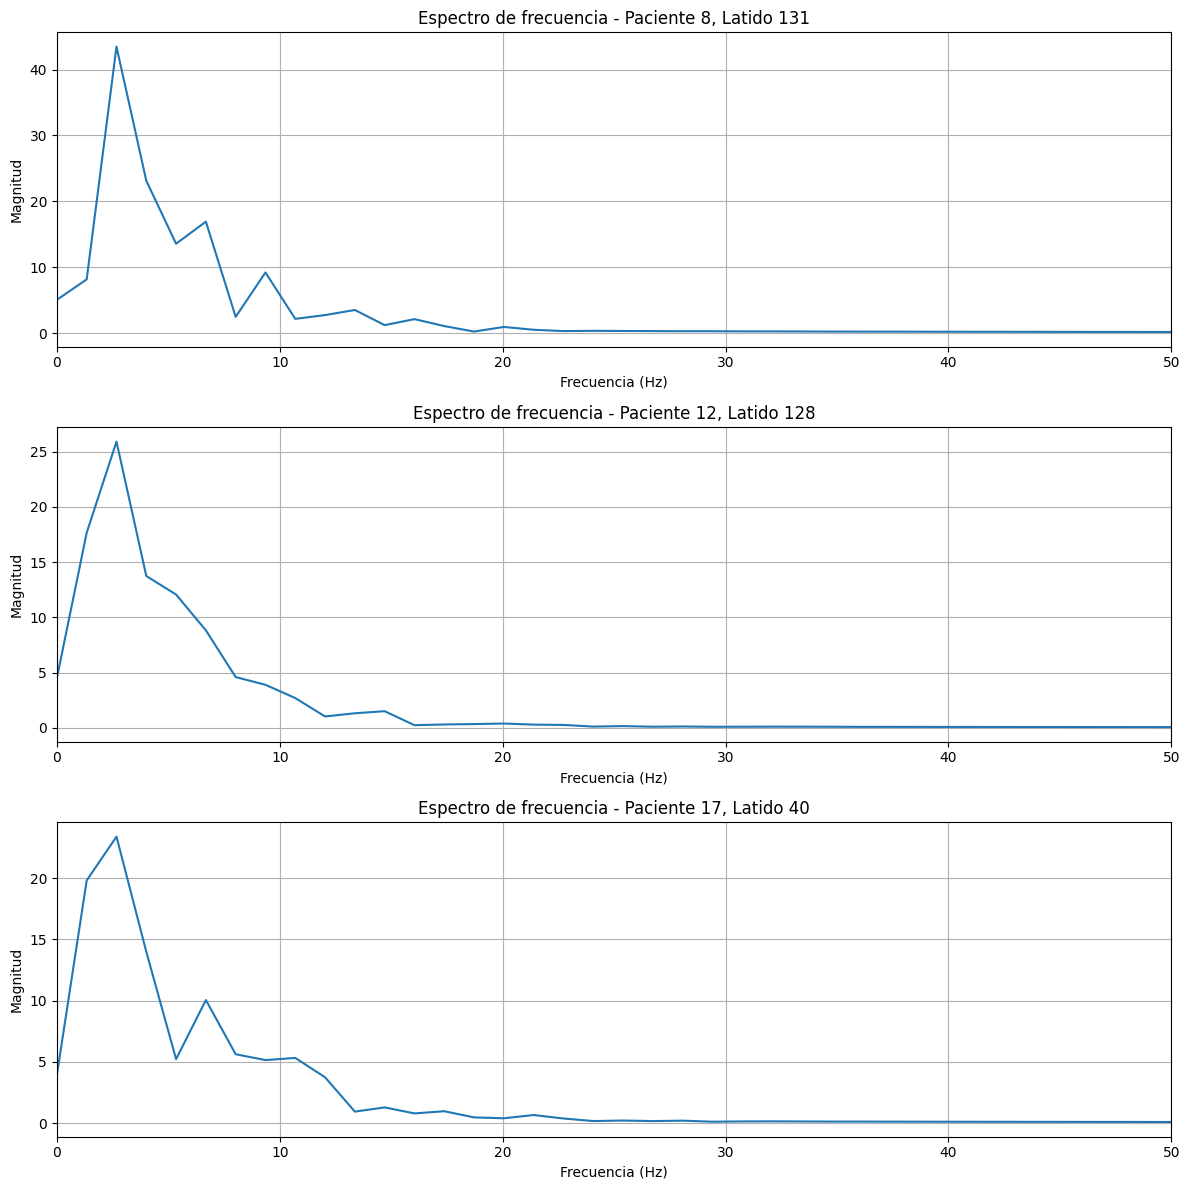

In [10]:
def plot_fft_of_segments(df, fs=250, num_signals=3):
    selected = df.sample(n=num_signals, random_state=1)
    plt.figure(figsize=(12, 4 * num_signals))

    for i, (_, row) in enumerate(selected.iterrows()):
        signal = row['Segment']
        N = len(signal)
        freq = np.fft.rfftfreq(N, d=1/fs)
        fft_vals = np.abs(np.fft.rfft(signal))

        plt.subplot(num_signals, 1, i + 1)
        plt.plot(freq, fft_vals)
        plt.title(f'Espectro de frecuencia - Paciente {row["PatientID"]}, Latido {row["BeatNumber"]}')
        plt.xlabel('Frecuencia (Hz)')
        plt.ylabel('Magnitud')
        plt.grid(True)
        plt.xlim(0, 50)  # Nos centramos en el rango de interés

    plt.tight_layout()
    plt.show()
plot_fft_of_segments(df_segments)


Now we can observe that frequency range is between 0.5 and 20 Hz.

Next, we want to create a second dataset which, unlike the previous one, will include all subcomplexes except for subcomplex u. This is done so that, during clustering, subcomplexes of type u do not introduce noise, as they do not provide any useful information about the ICG.

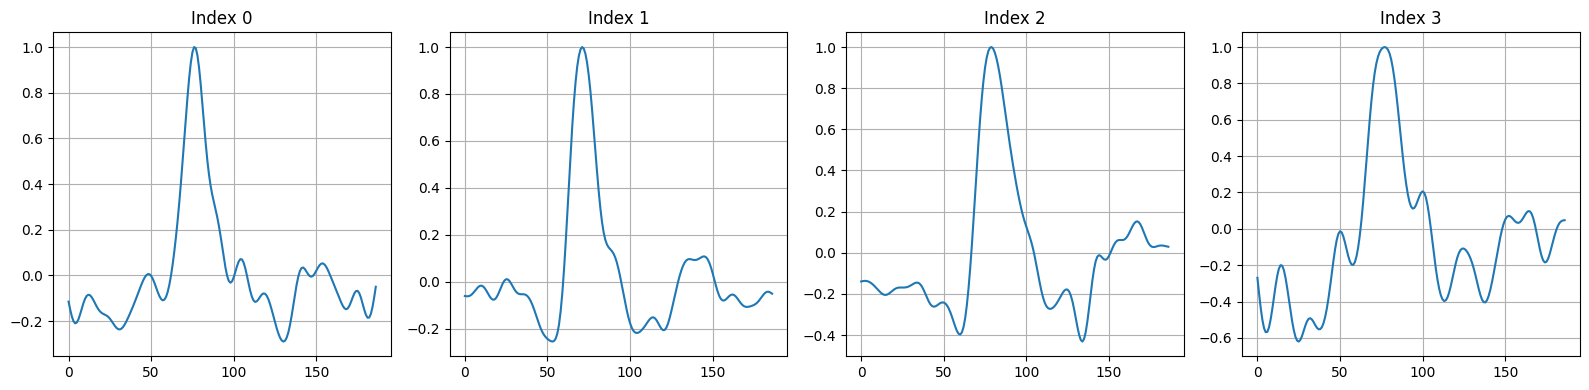

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


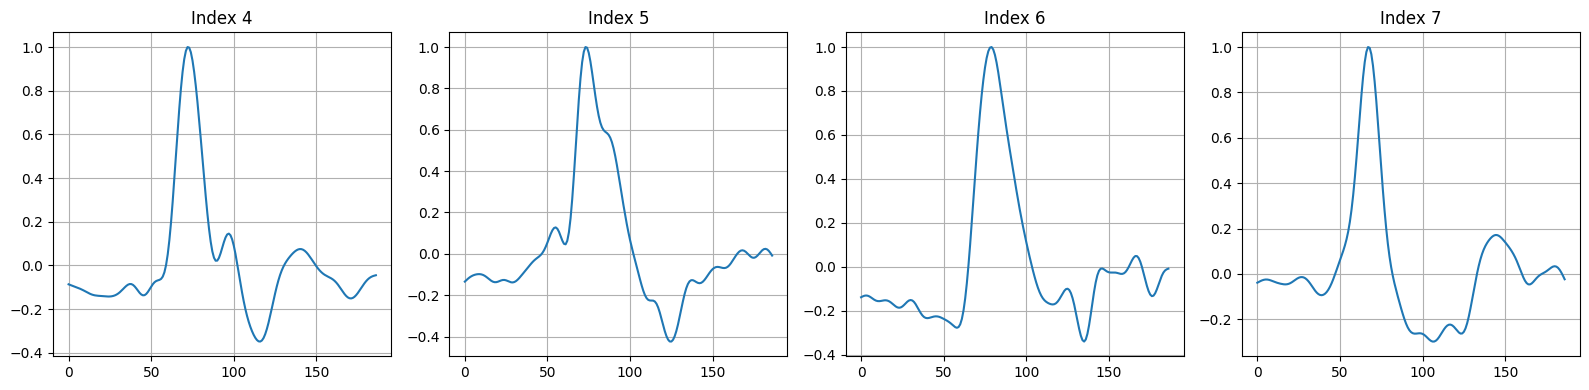

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


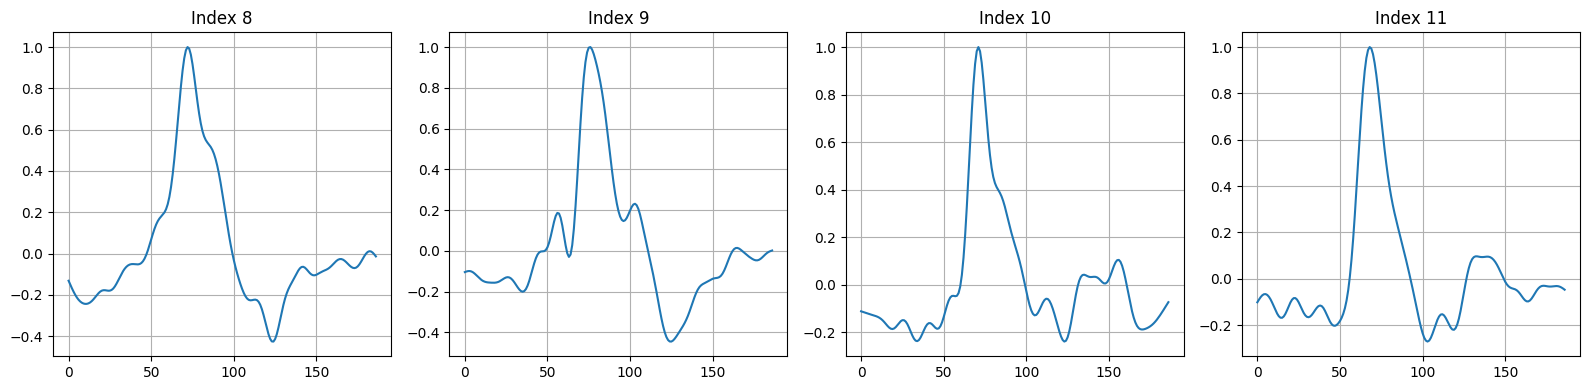

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


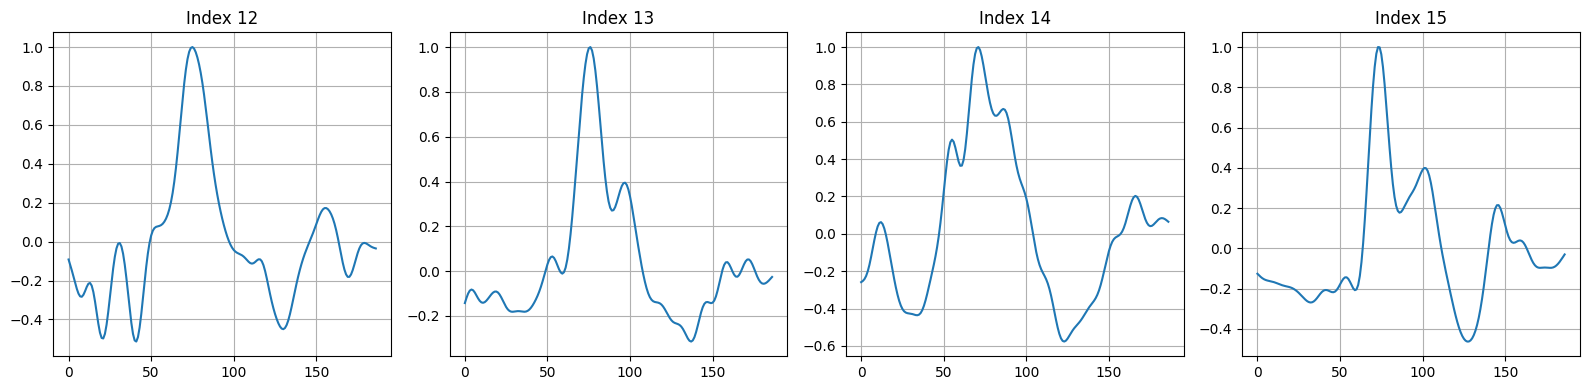

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


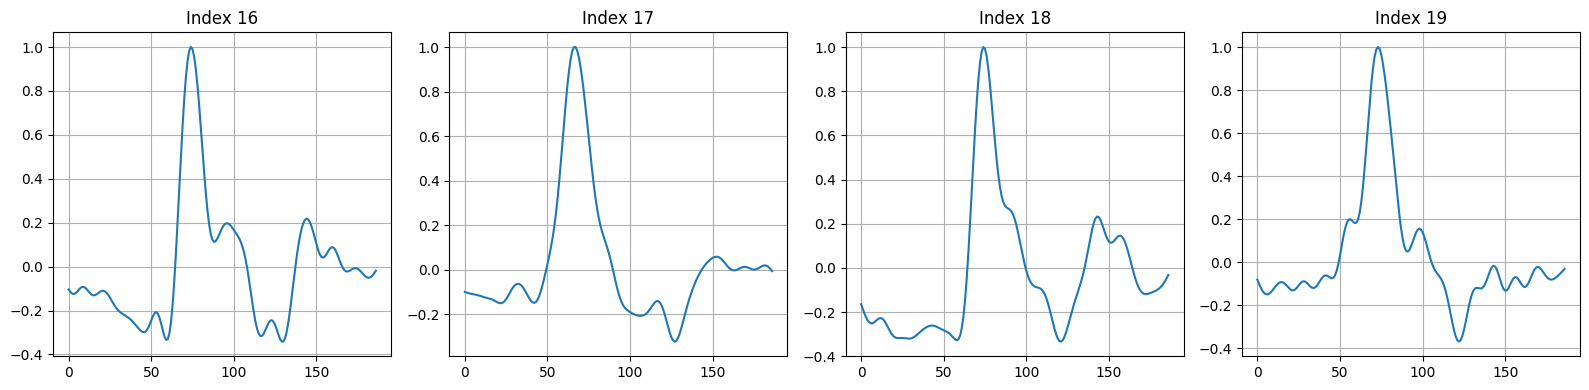

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


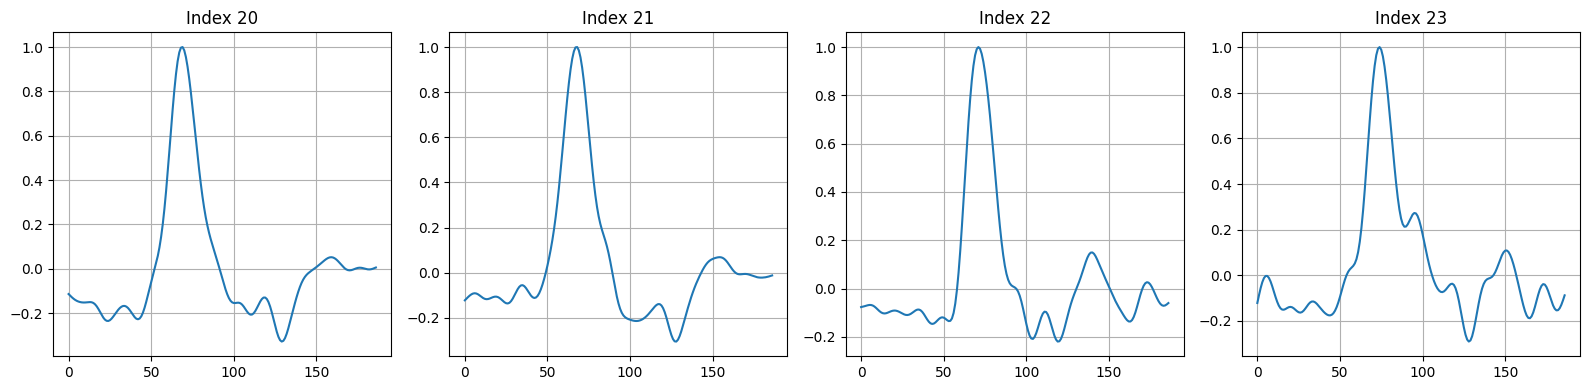

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


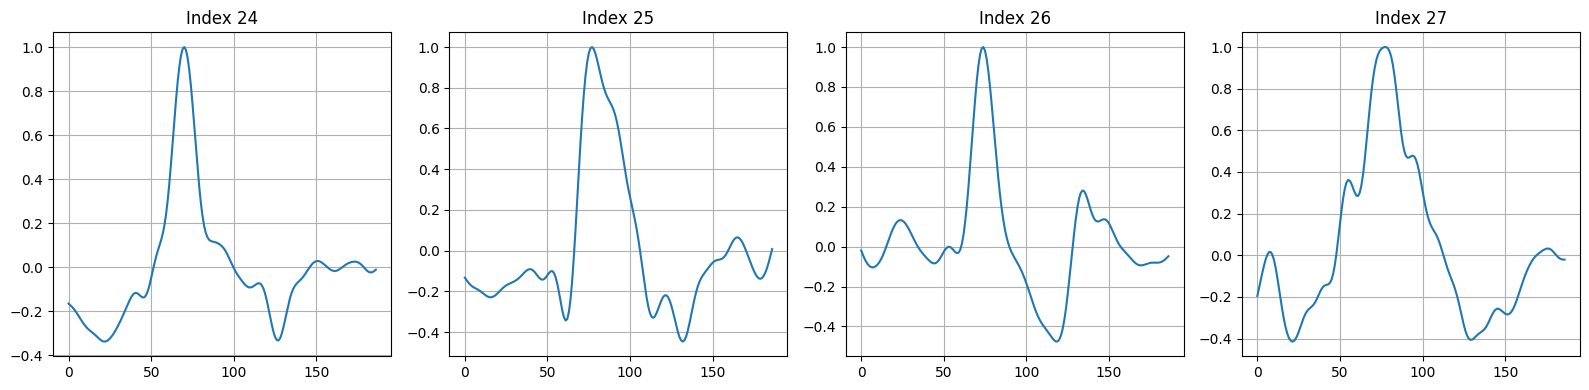

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


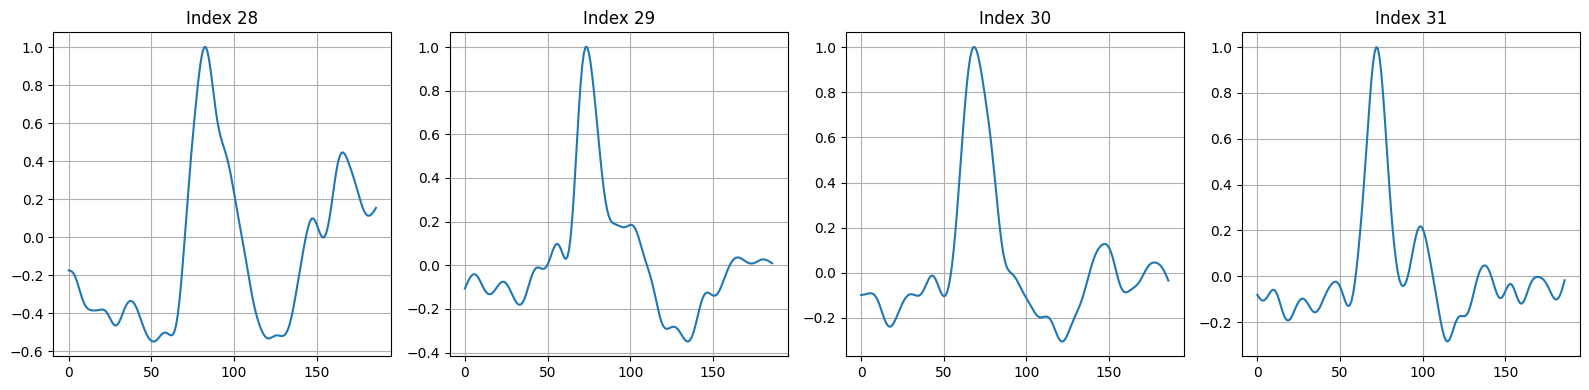

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


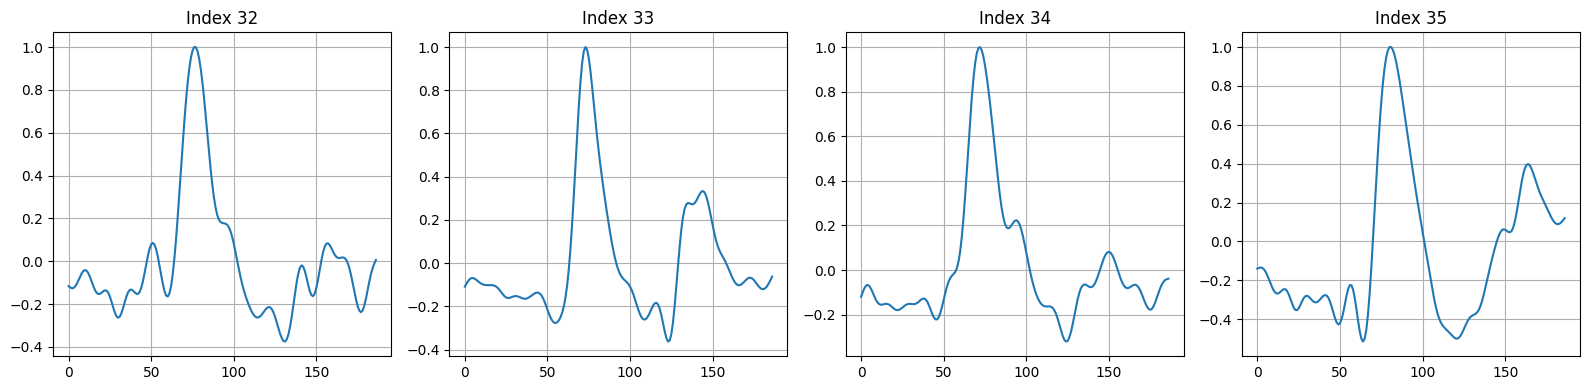

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


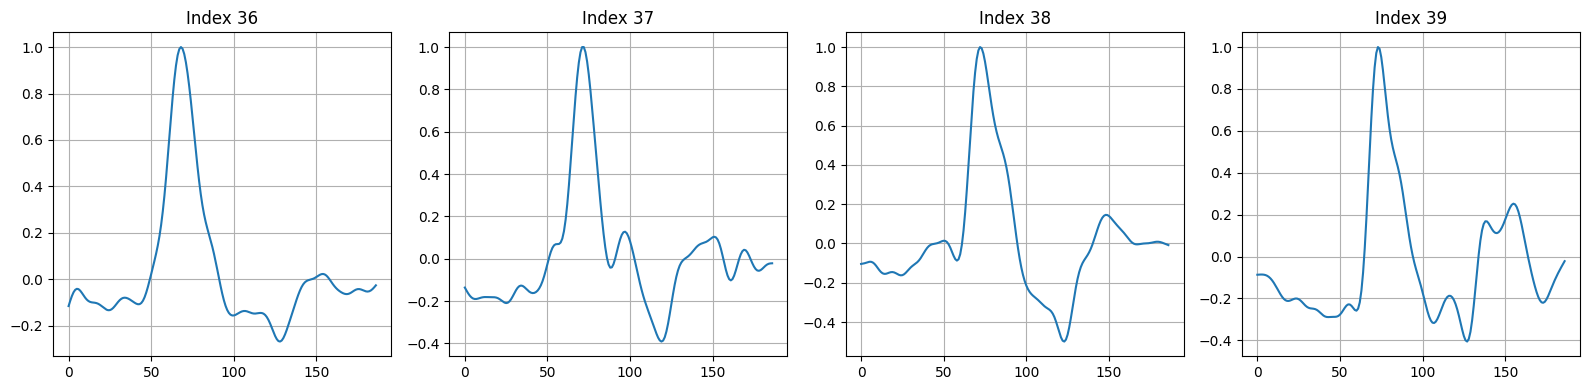

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


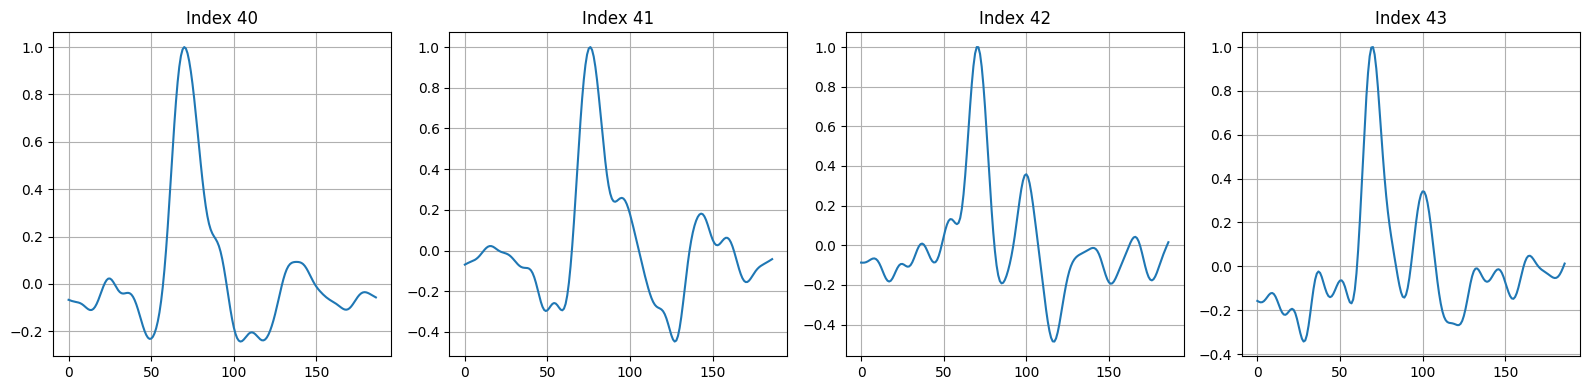

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


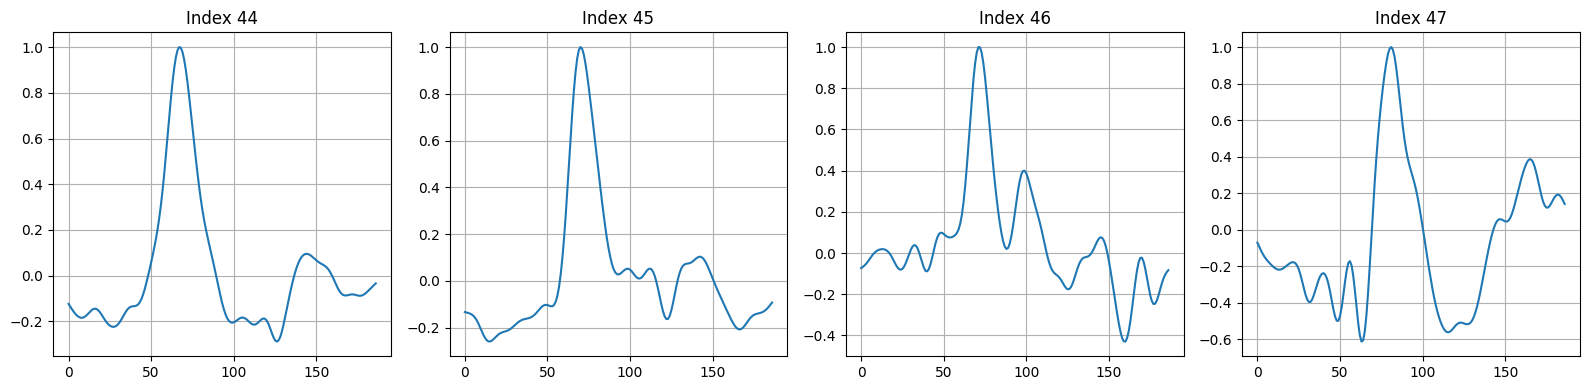

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


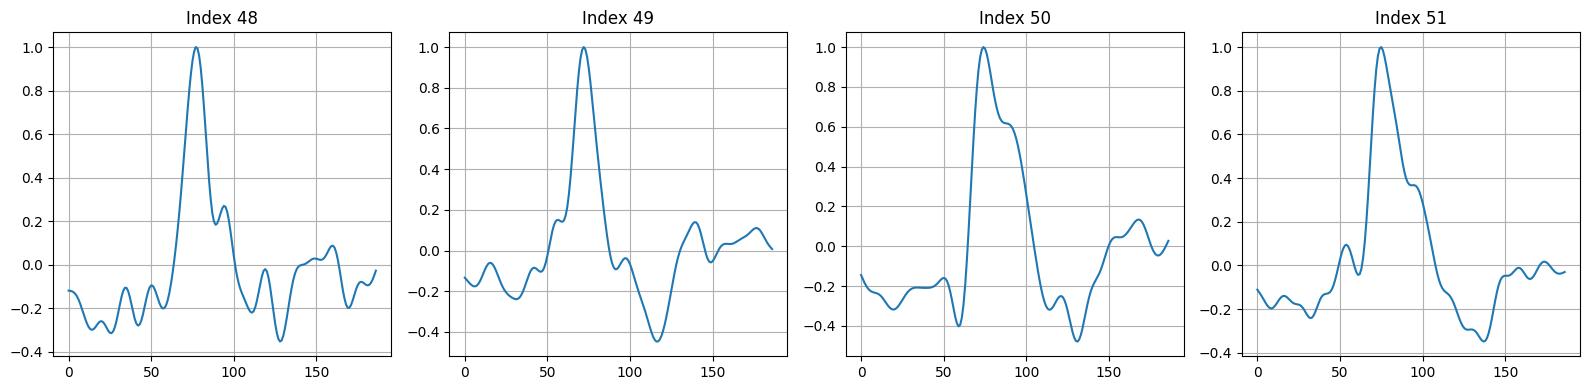

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


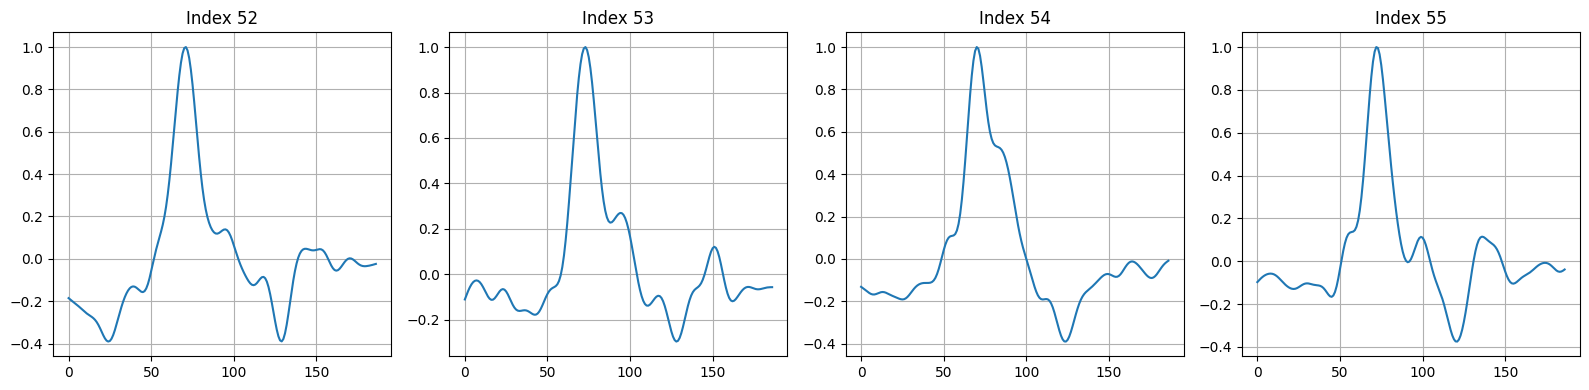

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


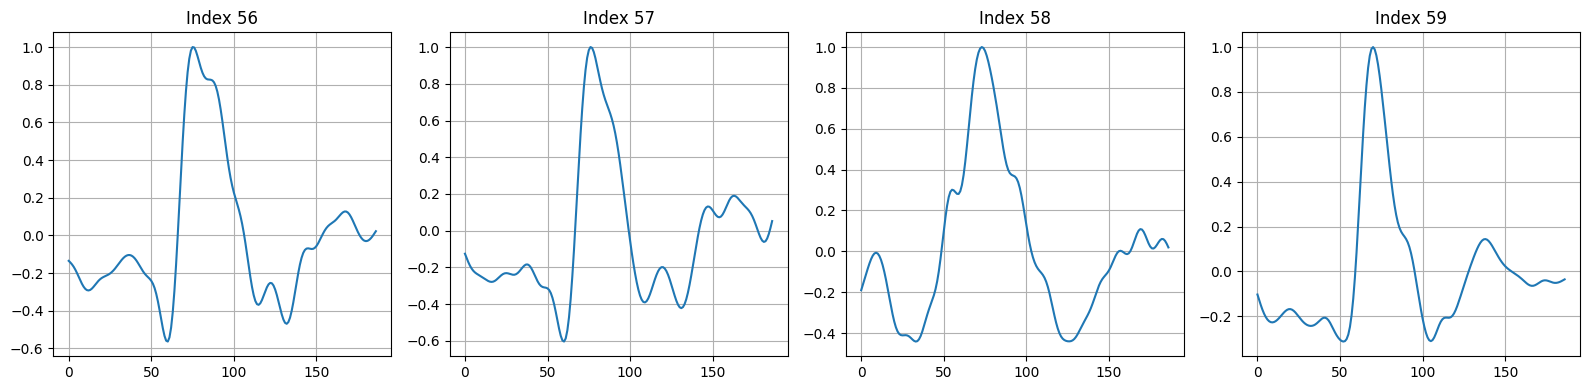

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


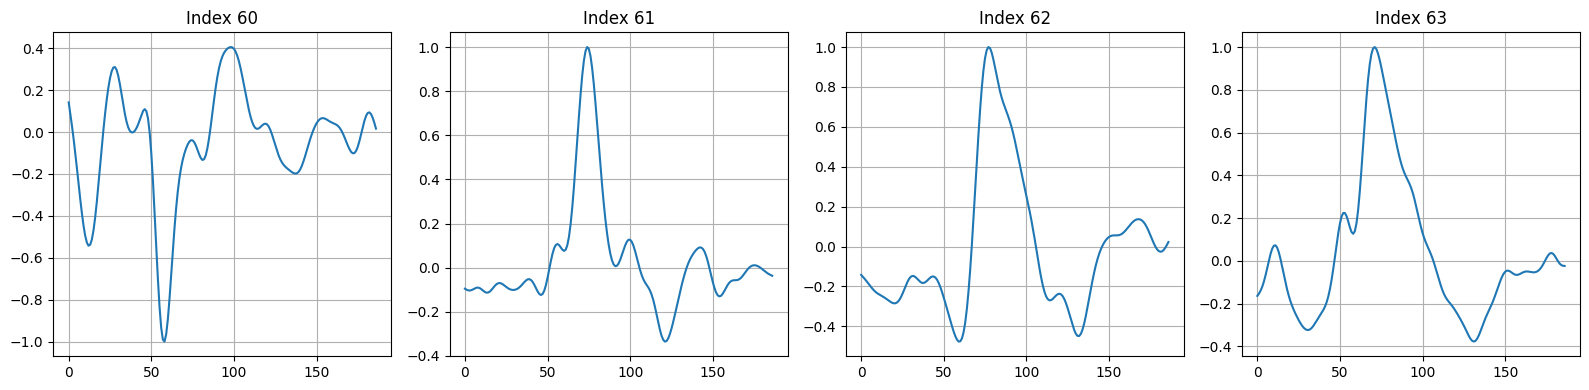

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: U V V V 


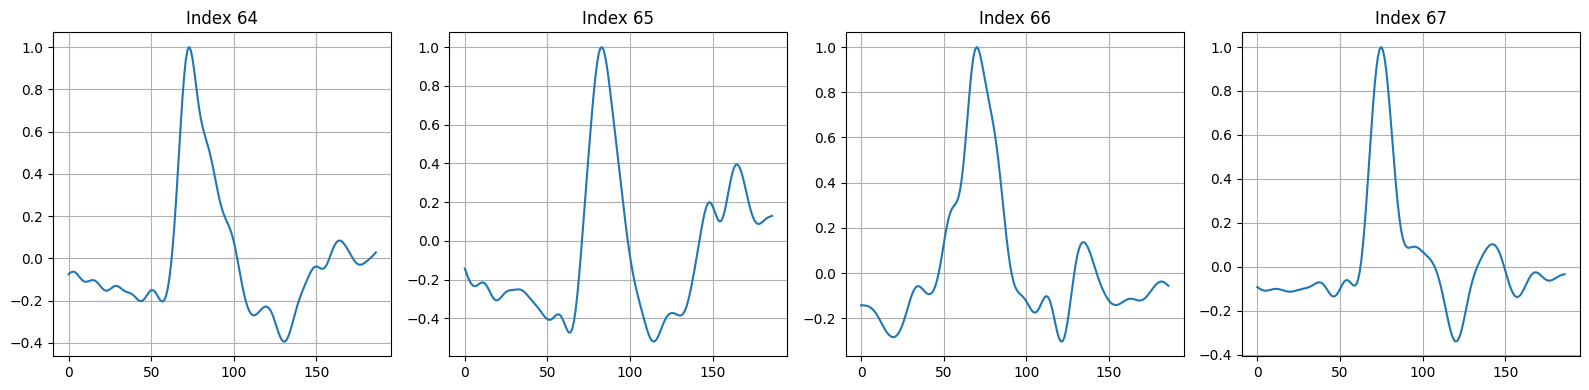

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


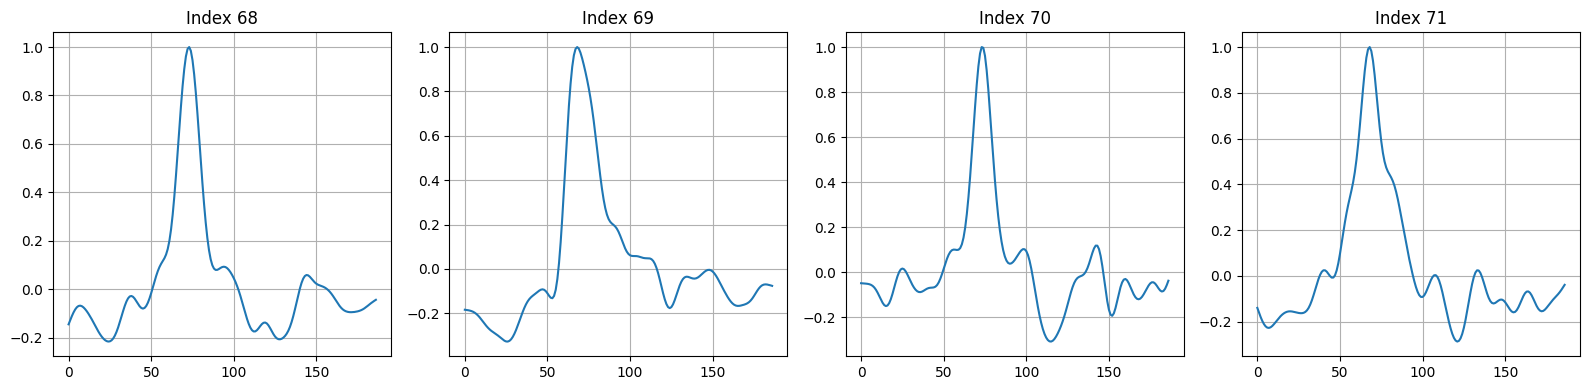

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


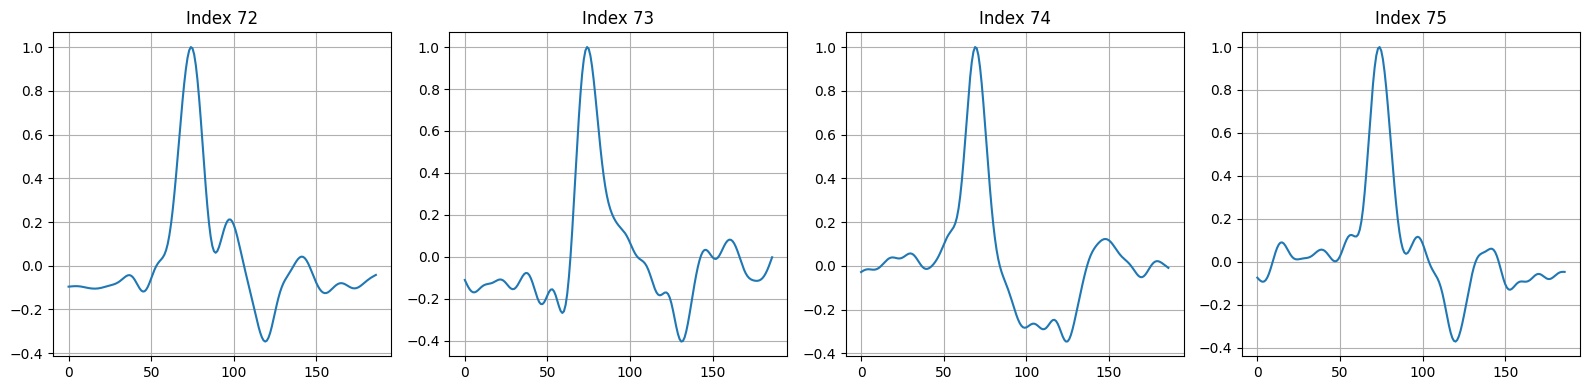

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


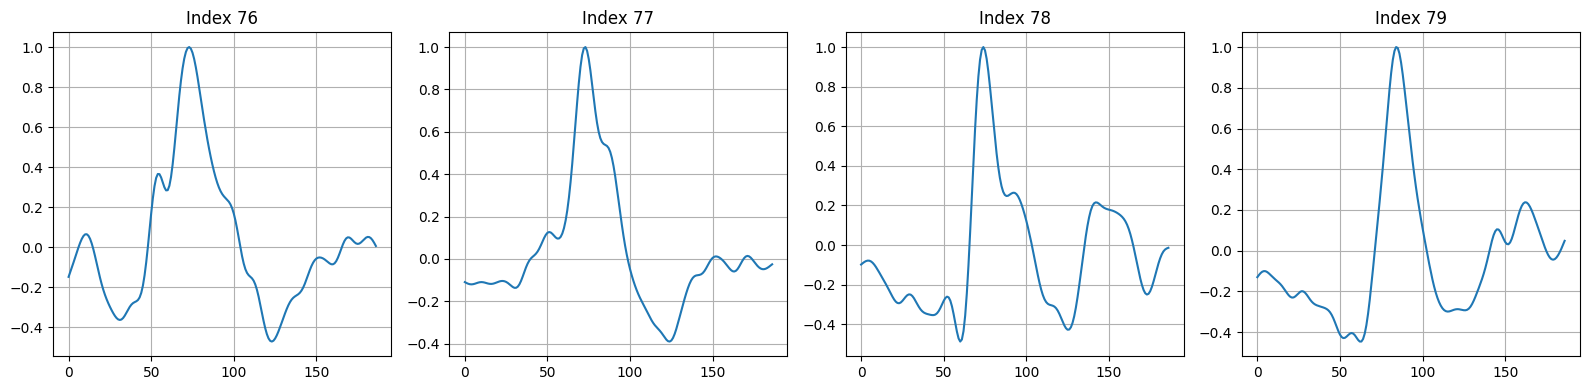

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


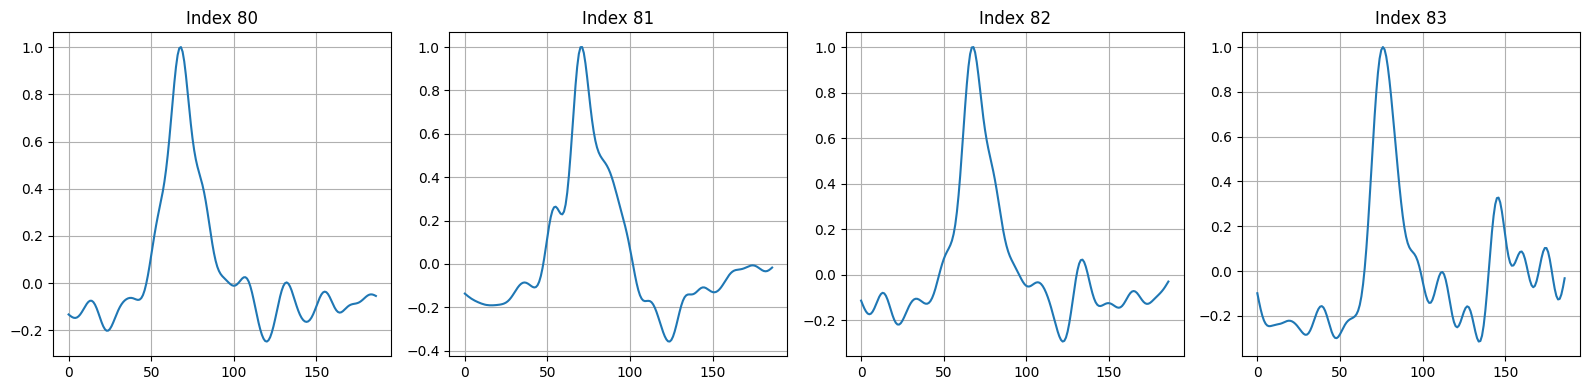

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


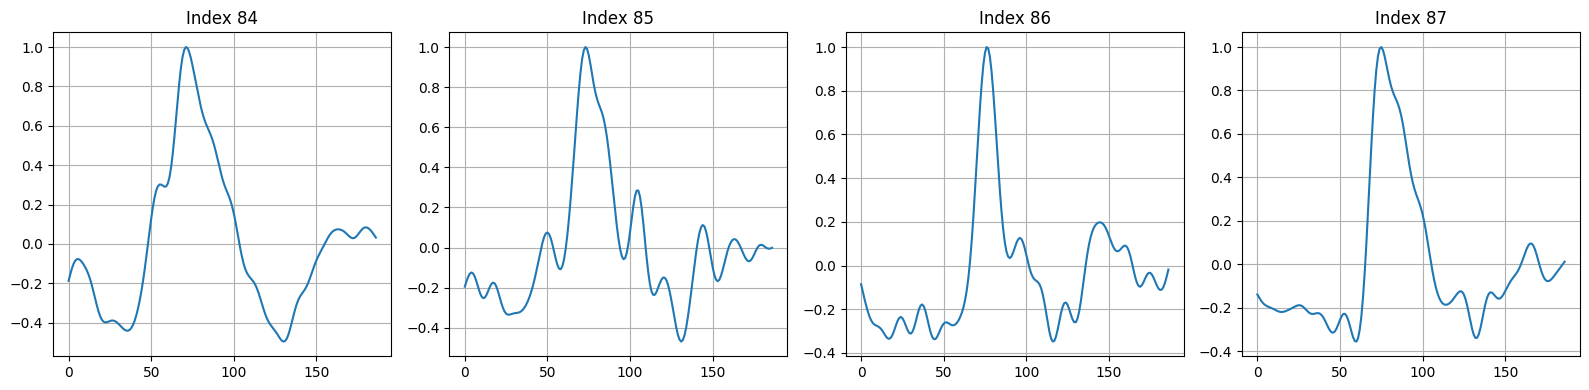

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


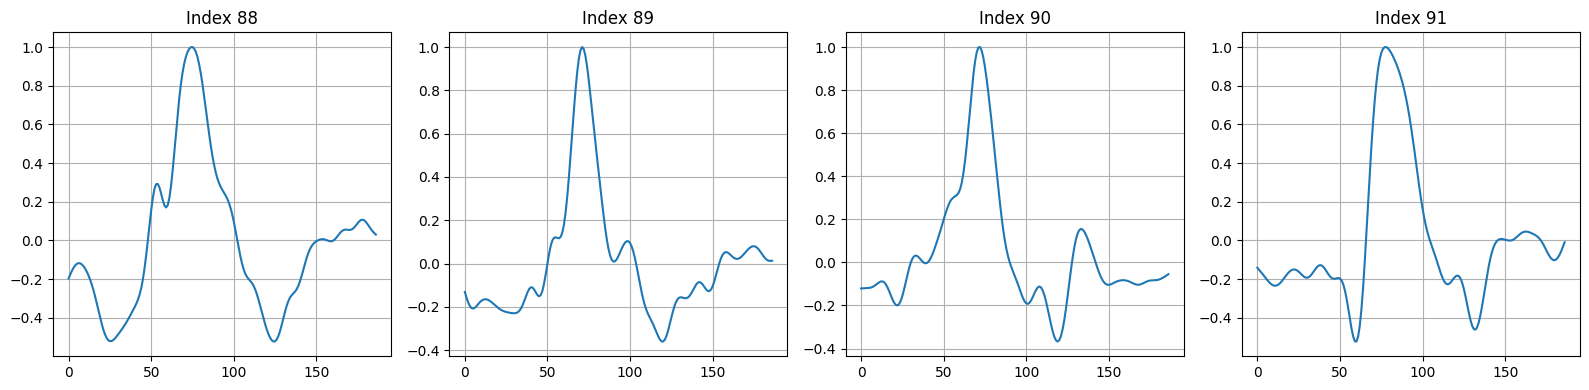

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


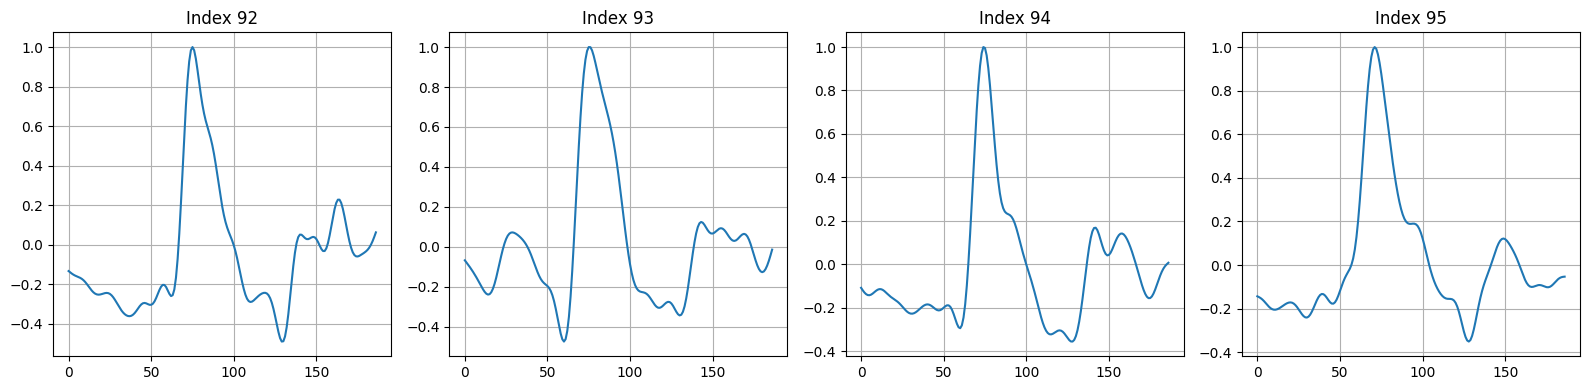

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


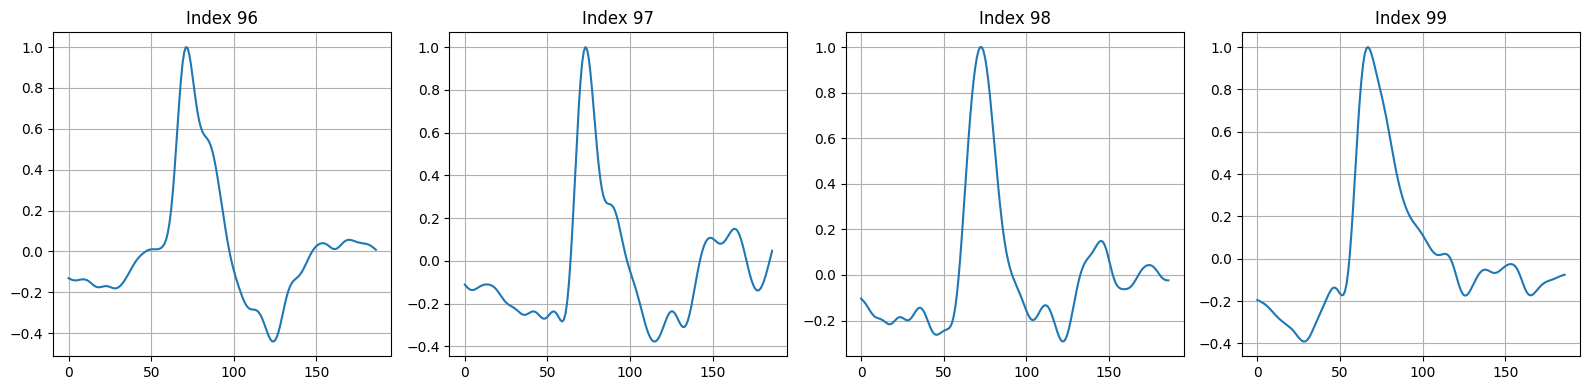

Introduce 4 etiquetas separadas por espacio (V para válido, U para inválido).


Etiquetas: V V V V


In [12]:
# Número de muestras para etiquetar manualmente
num_samples = 100
batch_size = 4    # Cuántos gráficos mostramos a la vez

# Seleccionar segmentos aleatorios
random.seed()
sampled_df = df_segments.sample(n=num_samples, random_state=42).reset_index(drop=True)

# Lista para almacenar las etiquetas
labels = []

# Recorrer en batches
for batch_start in range(0, num_samples, batch_size):
    batch_end = min(batch_start + batch_size, num_samples)
    batch = sampled_df.iloc[batch_start:batch_end]

    # Crear subgráficos para mostrar los segmentos
    fig, axs = plt.subplots(1, len(batch), figsize=(16, 4))

    if len(batch) == 1:
        axs = [axs]  # Para que axs sea siempre iterable

    for ax, (_, row) in zip(axs, batch.iterrows()):
        segment = row['Segment']
        ax.plot(segment)
        ax.set_title(f"Index {row.name}")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

    # Mostrar mensaje de solicitud de etiquetas
    print(f"Introduce {len(batch)} etiquetas separadas por espacio (V para válido, U para inválido).")

    # Esperar que el usuario ingrese etiquetas en la siguiente celda
    display(HTML(f'<b>Por favor ingresa las etiquetas para los segmentos mostrados (separadas por espacios):</b>'))

    # Pausar para permitir que el usuario ingrese las etiquetas en la siguiente celda
    #input("Cuando hayas ingresado las etiquetas, presiona Enter para continuar...")

    # Solicitar etiquetas después de la visualización
    while True:
        batch_labels = input("Etiquetas: ").upper().split()

        if len(batch_labels) == len(batch) and all(l in ['V', 'U'] for l in batch_labels):
            break
        else:
            print("Error: debes introducir exactamente una etiqueta V o U por cada segmento mostrado.")

    labels.extend(batch_labels)

# Añadir las etiquetas al DataFrame
sampled_df['Label'] = labels

# Guardar el DataFrame con las etiquetas
sampled_df.to_csv("icg_labeled_V_U.csv", index=False)


Train a Random Forest model that, based on features extracted from each segment and the previously provided labels, is able to automatically classify each of the segments.


In [13]:
# Función para extraer características simples de cada segmento
def extract_features(segments):
    features = []
    for segment in segments:
        mean = np.mean(segment)
        std = np.std(segment)
        max_val = np.max(segment)
        min_val = np.min(segment)
        skewness = skew(segment)
        kurt = kurtosis(segment)
        features.append([mean, std, max_val, min_val, skewness, kurt])
    return np.array(features)

# Extraer características del df que yo he clasificado como U o V
X = extract_features(sampled_df['Segment'])
y = sampled_df['Label'].apply(lambda x: 1 if x == 'V' else 0)  # Convertir 'V' a 1 y 'U' a 0

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar el modelo Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Evaluar el modelo
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        30

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [14]:
# Asumimos que df_segments contiene todos los segmentos restantes
#Extraemos características de todos los segmentos del df
X_all = extract_features(df_segments['Segment'])

# Predecir etiquetas para el resto de los segmentos
y_all_pred = rf.predict(X_all)

# Convertir las predicciones de 0 y 1 de nuevo a 'V' y 'U'
df_segments['Predicted_Label'] = ['V' if label == 1 else 'U' for label in y_all_pred]

# Guardar el DataFrame con las predicciones
df_segments.to_csv("icg_segments_with_predictions.csv", index=False)


Pie chart to visualize the distribution of segments U and V.


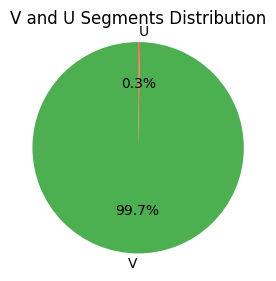

In [15]:
# Contar la cantidad de segmentos de tipo V y U
label_counts = df_segments['Predicted_Label'].value_counts()

# Graficar distribución de segmentos V y U
plt.figure(figsize=(3, 3))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FF6347'])
plt.title("V and U Segments Distribution")
plt.axis('equal')  # Asegura que el gráfico sea un círculo
plt.show()


Code to visualize multiple U segments and verify:

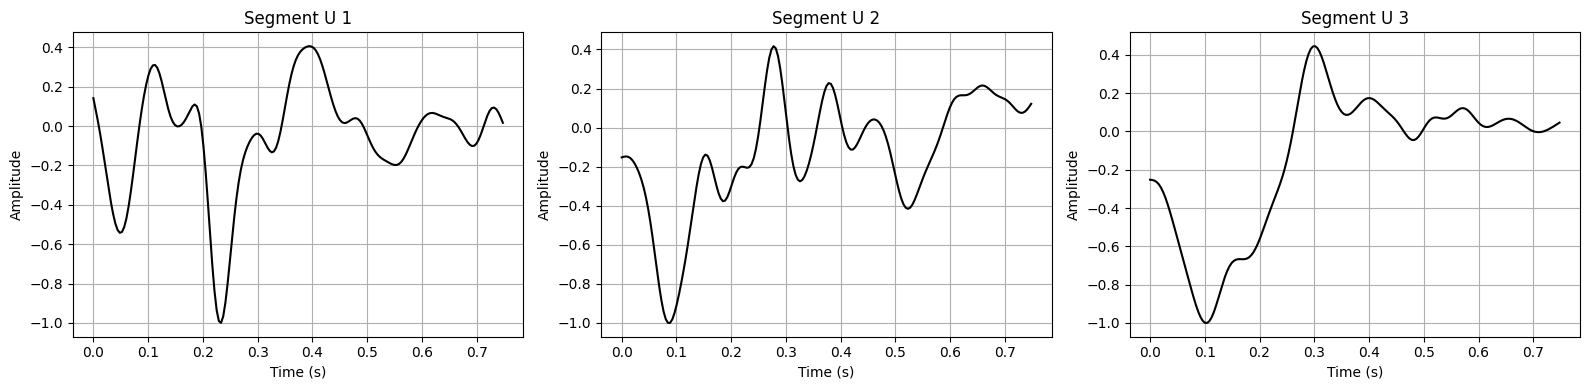

In [16]:
# Filtrar los segmentos clasificados como 'U'
u_segments = df_segments[df_segments['Predicted_Label'] == 'U']

# Seleccionar un número aleatorio de segmentos 'U' para visualizar
num_segments_to_show = 3
random_u_segments = u_segments.sample(n=num_segments_to_show, random_state=42)

# Graficar los segmentos 'U' seleccionados
plt.figure(figsize=(16, 4))

for i, (_, row) in enumerate(random_u_segments.iterrows()):
    segment = np.array(row['Segment'])
    time_vector = np.linspace(0, len(segment) / fs, len(segment))  # Tiempo en segundos

    plt.subplot(1, num_segments_to_show, i + 1)
    plt.plot(time_vector, segment, color='black')
    plt.title(f"Segment U {i+1}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()


Alright, we now have that the table icg_segments_with_predictions includes a new column indicating whether the segments are valid (V) or invalid (subcomplex U). Finally, the dataframe we will use in the following code will not be the entire one, but only the rows where the prediction column contains a V.

In [17]:
# Filtrar los segmentos clasificados como 'V' (válidos)
v_segments = df_segments[df_segments['Predicted_Label'] == 'V']
#A partir de ahora he de emplear esto apra referirme a los segmentos de icg filtrados (sin los subcomplejos u)

# Guardar los segmentos V en un nuevo archivo CSV
v_segments.to_csv("icg_segments_validos.csv", index=False)

print("Archivo 'icg_segments_validos.csv' guardado exitosamente.")

Archivo 'icg_segments_validos.csv' guardado exitosamente.


###Delineation Algorithm of each Characteristic Point:

####C point detection:

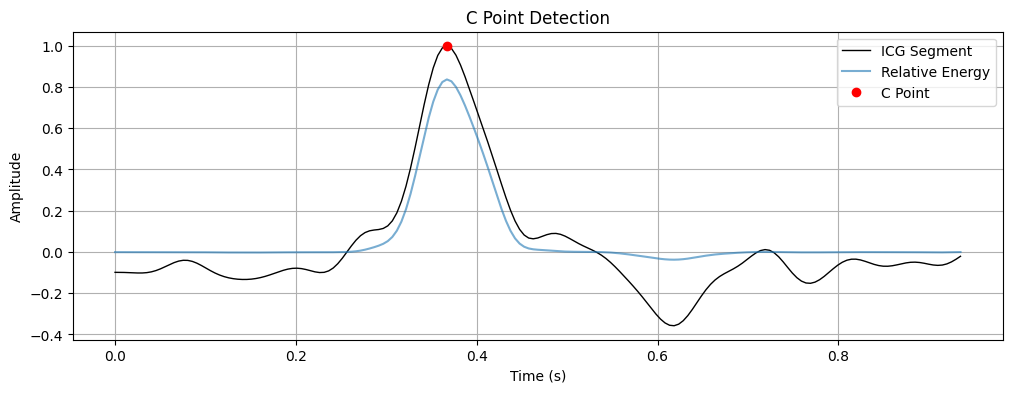

In [18]:
def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)

    for n in range(len(signal)):
        i1 = max(0, n - long_len // 2)
        i2 = min(len(signal), n + long_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)

        j1 = max(0, n - short_len // 2)
        j2 = min(len(signal), n + short_len // 2)
        short_energy = np.sum(signal[j1:j2] ** 2)

        if long_energy != 0:
            c = short_energy / long_energy
            Xre[n] = signal[n] * c
    return Xre

def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)

    # Thresholds
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 and sorted_peaks[-2] > np.mean(Xre) else sorted_peaks[-1]

    Thr_max = 0.2 * maxval
    Thr_min = 0.02 * maxval

    C_peaks = []
    active = False
    start_idx = 0

    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active = True
            start_idx = i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if len(C_peaks) == 0 or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    # Filtrar según intervalos C-C
    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            if len(prev_cc) == 5:
                avg_cc = np.mean(prev_cc)
                if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                    final_C_peaks.append(p)
            else:
                final_C_peaks.append(p)

    return np.array(final_C_peaks), Xre

#Cogemos un segmento de icg cuya etiqueta sea V
icg_segment = v_segments['Segment'].iloc[1000]
fs=200
C_peaks, Xre = detect_C_peaks(icg_segment, fs)

#Definimos el tiempo para representar en función del tiempo en lugar de muestras
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Representación
plt.figure(figsize=(12, 4))
plt.plot(tiempo, icg_segment, label="ICG Segment", color='black', linewidth=1)
plt.plot(tiempo, Xre, label="Relative Energy", alpha=0.6)
plt.plot(tiempo[C_peaks], icg_segment[C_peaks], 'ro', label="C Point")
plt.legend()
plt.title("C Point Detection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


####B point detection:

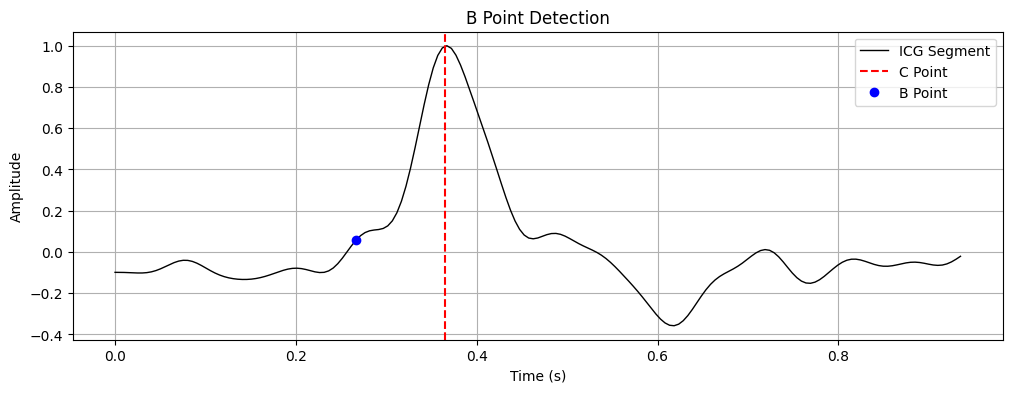

In [19]:
def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    # Paso 1: calcular límites de la ventana de búsqueda
    BlimL = max(0, int(Cpos - 0.1 * fs))  # 80 ms antes del C
    C_amp = icg_segment[Cpos]

    # Buscar BlimR: el índice más cercano a la izquierda donde la señal < Afrac * C_amp
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * C_amp:
            BlimR = i
            break
    else:
        BlimR = BlimL  # Si no se encuentra, que sea igual al límite inferior

    # Derivada primera (pendiente) de la señal
    slope = np.gradient(icg_segment)

    # Paso 2: búsqueda con Bslope1
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and (icg_segment[i] < icg_segment[i-1])) or abs(slope[i]) > Bslope1:
            return i

    # Paso 3: búsqueda con Bslope2
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i

    # Paso 4: si no se encuentra, retornar el mínimo de la ventana
    search_region = icg_segment[BlimL:BlimR+1]
    return BlimL + np.argmin(search_region)

B_points = []
for Cpos in C_peaks:
    B_idx = find_B_point(icg_segment, Cpos, fs)
    B_points.append(B_idx)

# Visualización
plt.figure(figsize=(12, 4))
plt.plot(tiempo, icg_segment, label="ICG Segment", color='black', linewidth=1)
plt.axvline(x=C_peaks / fs, color='red', linestyle='--', label='C Point')
#plt.plot(tiempo[C_peaks], icg_segment[C_peaks], 'ro', label="C Point")
plt.plot(tiempo[B_points], icg_segment[B_points], 'bo', label="B Point")
plt.legend()
plt.title("B Point Detection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


####X point detection:

<ipython-input-20-36de405af214>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-20-36de405af214>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


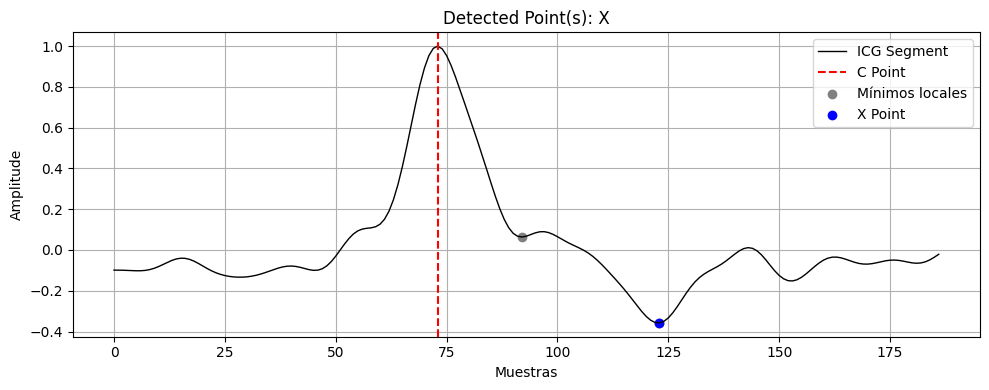

{'caso': 'X', 'X': np.int64(123)}


In [20]:
def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):

    # 1. Definir ventana temporal (0.1s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        # Tomar los dos primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]

        # Comparar amplitudes
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) >= 3:
        # Tomar los tres primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]
        X3_idx = min_indices[2]

        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}

        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # 6. Graficar resultados
    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(icg_segment, label='ICG Segment', color='black', linewidth=1)
        plt.axvline(x=C_index, color='red', linestyle='--', label='C Point')

        # Ajustar índices locales a posición original
        min_plot_idx = min_indices + start
        plt.scatter(min_plot_idx, icg_segment[min_plot_idx], color='gray', label='Mínimos locales')

        if resultado["caso"] == "X":
            plt.scatter(resultado["X"] + start, icg_segment[resultado["X"] + start], color='blue', label='X Point')
        elif resultado["caso"] == "X1":
            plt.scatter(resultado["X1"] + start, icg_segment[resultado["X1"] + start], color='orange', label='X1 Point')
        elif resultado["caso"] == "X1_X2":
                plt.scatter(resultado["X1"] + start, icg_segment[resultado["X1"] + start],
                color='orange', label='X1 Point')
                plt.scatter(resultado["X2"] + start, icg_segment[resultado["X2"] + start],
                color='blue', label='X2 Point')
        plt.title(f"Detected Point(s): {resultado['caso']}")
        plt.xlabel("Muestras")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


    # Ajustar índices al segmento original
    if resultado["caso"] == "X":
        resultado["X"] = resultado["X"] + start
    elif resultado["caso"] == "X1":
        resultado["X1"] = resultado["X1"] + start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] = resultado["X1"] + start
        resultado["X2"] = resultado["X2"] + start

    return resultado

segmento = v_segments['Segment'].iloc[1000]
fs = 200
C_index, _ = detect_C_peaks(segmento, fs)

resultado = detectar_punto_X(segmento, C_index, fs, plot=True)
print(resultado)

Detection versus time

<ipython-input-21-f1aae64037dc>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-21-f1aae64037dc>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


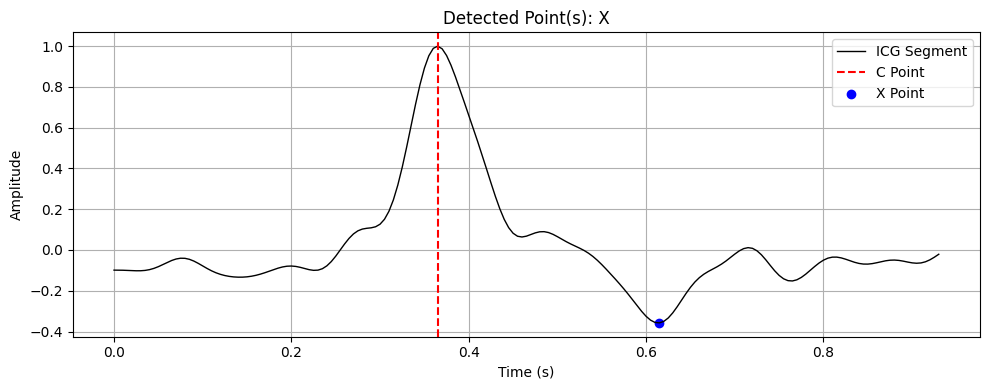

{'caso': 'X', 'X': np.int64(123)}


In [21]:
def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):

    # 1. Definir ventana temporal (0.1s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        # Tomar los dos primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]

        # Comparar amplitudes
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset
        idx = min_indices[0]

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif idx == abs_min_idx :
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) >= 3:
        # Tomar los tres primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]
        X3_idx = min_indices[2]

        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset
        idx = min_indices[0]

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif idx == abs_min_idx :
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}

        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # 6. Graficar resultados
    # 5. Clasificación según mínimos detectados
    # [ ... aquí tu lógica de detección ... ]

    # 🔁 Ajustar índices al segmento original ANTES de graficar
    if resultado["caso"] == "X":
        resultado["X"] = resultado["X"] + start
    elif resultado["caso"] == "X1":
        resultado["X1"] = resultado["X1"] + start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] = resultado["X1"] + start
        resultado["X2"] = resultado["X2"] + start

    # 6. Graficar resultados EN TIEMPO
    if plot:
        plt.figure(figsize=(10, 4))
        tiempo_segmento = np.arange(len(icg_segment)) / fs
        plt.plot(tiempo_segmento, icg_segment, label='ICG Segment', color='black', linewidth=1)
        plt.axvline(x=C_index / fs, color='red', linestyle='--', label='C Point')


        if resultado["caso"] == "X":
            plt.scatter(resultado["X"] / fs, icg_segment[resultado["X"]], color='blue', label='X Point')
        elif resultado["caso"] == "X1":
            plt.scatter(resultado["X1"] / fs, icg_segment[resultado["X1"]], color='orange', label='X1 Point')
        elif resultado["caso"] == "X1_X2":
            plt.scatter(resultado["X1"] / fs, icg_segment[resultado["X1"]], color='orange', label='X1 Point')
            plt.scatter(resultado["X2"] / fs, icg_segment[resultado["X2"]], color='blue', label='X2 Point')

        plt.title(f"Detected Point(s): {resultado['caso']}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return resultado

segmento = v_segments['Segment'].iloc[1000]
fs = 200
C_index, _ = detect_C_peaks(segmento, fs)

resultado = detectar_punto_X(segmento, C_index, fs, plot=True)
print(resultado)

####O point detection:

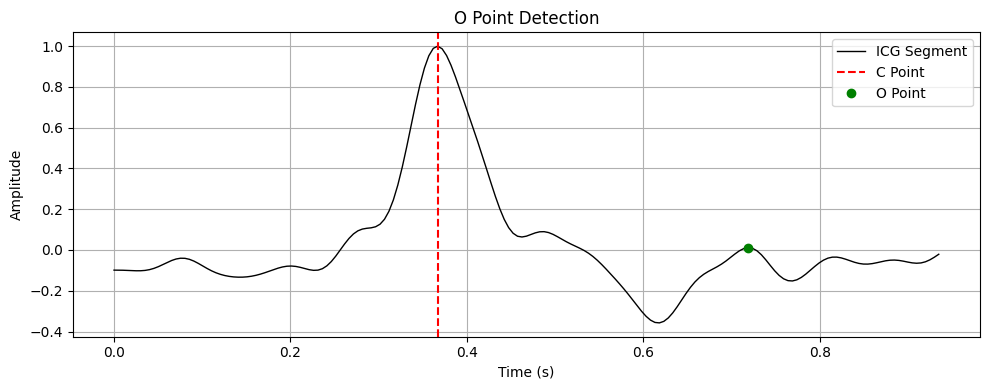

In [22]:
def detect_O_point(segment, C_index, fs):
    # Zona de búsqueda: 0.2s a 0.5s después del punto C
    start_search = C_index + int(0.2 * fs)
    end_search = C_index + int(0.5 * fs)
    end_search = min(end_search, len(segment))  # evitar salir del rango

    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Buscar máximos locales
    peaks, _ = signal.find_peaks(search_region)

    if len(peaks) == 0:
        return None

    # Elegir el pico de mayor amplitud
    peak_amplitudes = search_region[peaks]
    max_peak_idx = peaks[np.argmax(peak_amplitudes)]
    O_index = start_search + max_peak_idx
    return O_index

# Supongamos que tienes `C_peaks`, `icg_segment`, y `fs` definidos
if len(C_peaks) > 0:
    C_idx = C_peaks[0]
    O_idx = detect_O_point(icg_segment, C_idx, fs)

    # Representación
    tiempo = np.linspace(0, len(icg_segment) / fs, len(icg_segment))
    plt.figure(figsize=(10, 4))
    plt.plot(tiempo, icg_segment, label="ICG Segment", color='black', linewidth=1)

    # Punto C como línea discontinua roja
    plt.axvline(x=tiempo[C_idx], color='red', linestyle='--', label="C Point")

    # Punto O como marcador
    if O_idx is not None:
        plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="O Point")

    plt.legend()
    plt.title("O Point Detection")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


####Z point detection:

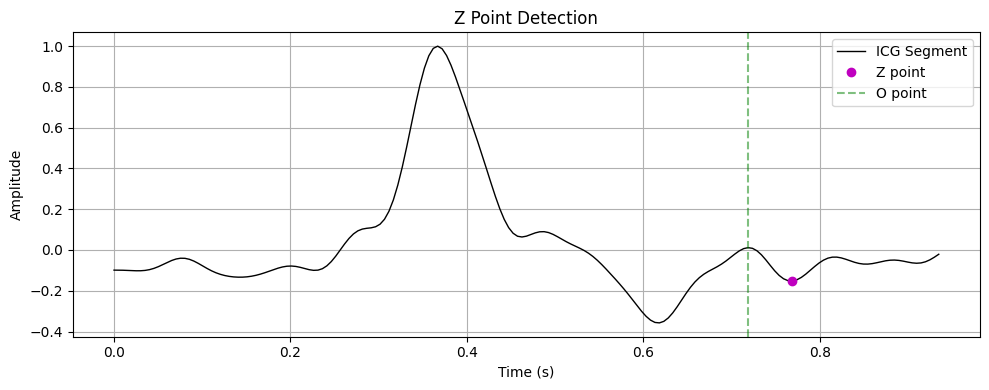

In [23]:
def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index

# Example of usage (assuming icg_segment, fs, and O_idx are defined)
Z_idx = detect_Z_point(icg_segment, O_idx, fs)

# Time vector for plotting
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Plotting the ICG signal with O and Z points
plt.figure(figsize=(10, 4))
plt.plot(tiempo, icg_segment, label="ICG Segment", color='black', linewidth=1,)
#plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="O point")
if Z_idx is not None:
    plt.plot(tiempo[Z_idx], icg_segment[Z_idx], 'mo', label="Z point")
    #plt.axvline(tiempo[Z_idx], color='m', linestyle='--', alpha=0.5)
plt.axvline(tiempo[O_idx], color='g', linestyle='--', alpha=0.5, label="O point")
plt.title("Z Point Detection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


####Y point detection:

<ipython-input-21-f1aae64037dc>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-21-f1aae64037dc>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


Usando X_idx en detectar_punto_Y: 123
No se detectaron mínimos locales entre X y O.


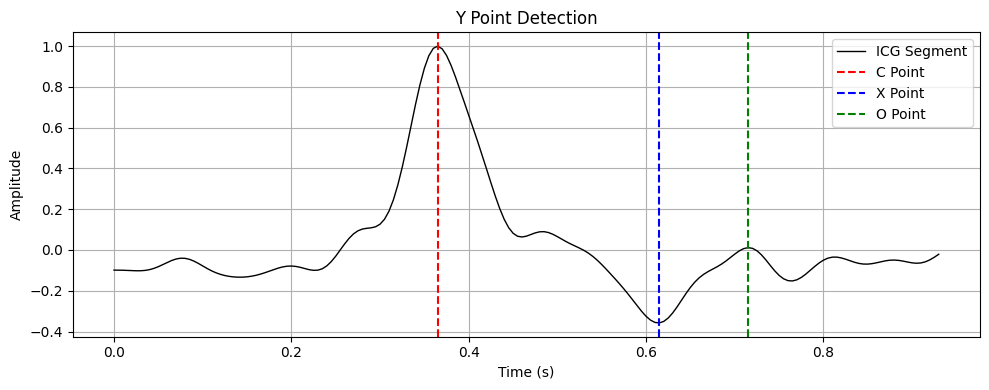

In [24]:
def detectar_punto_Y(icg_segment, resultado_X, O_index):
    # Determinar índice de inicio según el caso X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]  # usar X2 en este caso
    else:
        print("No se puede detectar Y: caso X no válido.")
        return None

    print("Usando X_idx en detectar_punto_Y:", X_idx)

    # Validar que X esté antes que O
    if X_idx >= O_index:
        print("No se puede detectar Y: X ocurre después de O.")
        return None

    # Extraer segmento entre X y O
    ventana_Y = icg_segment[X_idx:O_index + 1]

    # Buscar mínimos locales en esta ventana
    min_indices = argrelextrema(ventana_Y, np.less)[0]

    if len(min_indices) == 0:
        print("No se detectaron mínimos locales entre X y O.")
        return None

    # Tomar el mínimo local de menor amplitud
    Y_rel_idx = min_indices[np.argmin(ventana_Y[min_indices])]
    Y_abs_idx = X_idx + Y_rel_idx

    return Y_abs_idx


def plot_segmento_con_puntos(segmento, fs, C_idx=None, X_idx=None, O_idx=None, Y_idx=None):
    tiempo = np.arange(len(segmento)) / fs  # Convertir muestras a tiempo (s)

    plt.figure(figsize=(10, 4))
    plt.plot(tiempo, segmento, label="ICG Segment", color='black', linewidth=1)

    if C_idx is not None:
        plt.axvline(x=C_idx / fs, color='red', linestyle='--', label="C Point")
        # plt.scatter([C_idx / fs], [segmento[C_idx]], color='red')

    if X_idx is not None:
        plt.axvline(x=X_idx / fs, color='blue', linestyle='--', label="X Point")
        # plt.scatter([X_idx / fs], [segmento[X_idx]], color='blue')

    if O_idx is not None:
        plt.axvline(x=O_idx / fs, color='green', linestyle='--', label="O Point")
        # plt.scatter([O_idx / fs], [segmento[O_idx]], color='green')

    if Y_idx is not None:
        plt.scatter([Y_idx / fs], [segmento[Y_idx]], color='magenta', label="Y Point")

    plt.legend()
    plt.title("Y Point Detection")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

segmento = v_segments['Segment'].iloc[1000]
fs = 200
C_index, _ = detect_C_peaks(segmento, fs)
resultado = detectar_punto_X(segmento, C_index, fs, plot=False)
C_idx = C_index[0]
O_idx = detect_O_point(segmento, C_idx, fs)
Y_idx = detectar_punto_Y(segmento, resultado, O_idx)

# Aquí usas la función externa para plotear todos los puntos
if resultado["caso"] == "X":
    X_idx = resultado["X"]
elif resultado["caso"] == "X1":
    X_idx = resultado["X1"]
elif resultado["caso"] == "X1_X2":
    X_idx = resultado["X2"]
else:
    X_idx = None

plot_segmento_con_puntos(segmento, fs, C_idx=C_index[0], X_idx=X_idx, O_idx=O_idx, Y_idx=Y_idx)

###Delineation Algorithm of all Characteristic Points:

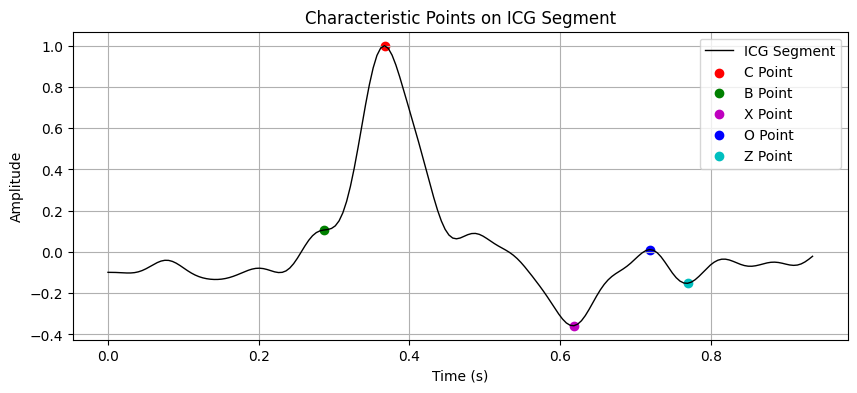

In [25]:
# ===================== #
#    1. FUNCIONES       #
# ===================== #

def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)
    for n in range(len(signal)):
        i1, i2 = max(0, n - long_len // 2), min(len(signal), n + long_len // 2)
        j1, j2 = max(0, n - short_len // 2), min(len(signal), n + short_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)
        short_energy = np.sum(signal[j1:j2] ** 2)
        if long_energy != 0:
            Xre[n] = signal[n] * (short_energy / long_energy)
    return Xre


def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 else sorted_peaks[-1]
    Thr_max, Thr_min = 0.2 * maxval, 0.02 * maxval

    C_peaks, active = [], False
    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active, start_idx = True, i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if not C_peaks or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            avg_cc = np.mean(prev_cc)
            if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                final_C_peaks.append(p)
    return np.array(final_C_peaks), Xre


def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    BlimL = max(0, int(Cpos - 0.08 * fs))
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * icg_segment[Cpos]:
            BlimR = i
            break
    else:
        BlimR = BlimL
    slope = np.gradient(icg_segment)
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and icg_segment[i] < icg_segment[i-1]) or abs(slope[i]) > Bslope1:
            return i
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i
    return BlimL + np.argmin(icg_segment[BlimL:BlimR+1])


def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):
    # 1. Definir ventana temporal (0.05s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        X1_idx, X2_idx = min_indices[0], min_indices[1]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    else:
        X1_idx, X2_idx, X3_idx = min_indices[:3]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # Ajuste de índices absolutos
    if resultado["caso"] == "X":
        resultado["X"] += start
    elif resultado["caso"] == "X1":
        resultado["X1"] += start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] += start
        resultado["X2"] += start

    return resultado


def detect_O_point(segment, C_index, fs):
    start_search = C_index + int(0.2 * fs)
    end_search = min(C_index + int(0.5 * fs), len(segment))
    search_region = segment[start_search:end_search]
    if len(search_region) == 0:
        return None
    peaks, _ = signal.find_peaks(search_region)
    if len(peaks) == 0:
        return None
    max_peak_idx = peaks[np.argmax(search_region[peaks])]
    return start_search + max_peak_idx


def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index



def detectar_punto_Y(icg_segment, resultado_X, O_index, fs):
    # Selección del índice de X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]
    else:
        return None

    if X_idx >= O_index:
        return None

    # Definir ventana temporal tras X
    min_offset = int(0.06 * fs)  # 60 ms
    max_offset = O_index
    inicio = X_idx + min_offset
    fin = min(X_idx + max_offset, O_index + 1)

    if fin <= inicio or fin > len(icg_segment):
        return None

    ventana_Y = icg_segment[inicio:fin]

    # Detectar mínimos locales
    min_idx = argrelextrema(ventana_Y, np.less)[0]

    for idx in min_idx:
        # Verificar que la curva baja antes y sube después (mínimo local "válido")
        if 1 <= idx < len(ventana_Y) - 1:
            if ventana_Y[idx - 1] > ventana_Y[idx] < ventana_Y[idx + 1]:
                return inicio + idx

    # Si no hay mínimos válidos con esa forma
    return None
# ===================== #
#     2. CARGA & PLOT   #
# ===================== #

fs = 200
segmento_idx = 1000
segmento = v_segments['Segment'].iloc[segmento_idx]

# Detectar todos los puntos
C_peaks, _ = detect_C_peaks(segmento, fs)
B_points = find_B_point(segmento, C_peaks[0], fs)
X_result = detectar_punto_X(segmento, C_peaks[0], fs)
O_point = detect_O_point(segmento, C_peaks[0], fs)
Z_point = detect_Z_point(segmento, O_point, fs)
Y_point = detectar_punto_Y(segmento, X_result, O_point, fs)

def plot_icg_with_points(icg_segment, fs,
                         C_idx, B_idxs, X_res, O_idx, Z_idx, Y_idx):
    time = np.linspace(0, len(icg_segment)/fs, len(icg_segment))
    plt.figure(figsize=(10,4))
    plt.plot(time, icg_segment, color='k', label='ICG Segment', linewidth=1)

    plt.scatter(time[C_idx], icg_segment[C_idx], color='r', label='C Point')
    plt.scatter(time[B_idxs], icg_segment[B_idxs], color='g', label='B Point')


    if X_res['caso']=='X':
        plt.scatter(time[X_res['X']], icg_segment[X_res['X']], color='m', label='X Point')
    elif X_res['caso']=='X1':
        plt.scatter(time[X_res['X1']], icg_segment[X_res['X1']], color='m', label='X1 Point')
    elif X_res['caso']=='X1_X2':
        plt.scatter(time[X_res['X1']], icg_segment[X_res['X1']], color='m', label='X1 Point')
        plt.scatter(time[X_res['X2']], icg_segment[X_res['X2']], color='y', label='X2 Point')

    if O_idx is not None:
        plt.scatter(time[O_idx], icg_segment[O_idx], color='b', label='O Point')

    if Z_idx is not None:
        plt.scatter(time[Z_idx], icg_segment[Z_idx], color='c', label='Z Point')

    if Y_idx is not None:
        plt.scatter(time[Y_idx], icg_segment[Y_idx], color='orange', label='Y Point')

    plt.legend()
    plt.title('Characteristic Points on ICG Segment')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()

# Llamada al plot
plot_icg_with_points(segmento, fs, C_peaks[0], B_points, X_result, O_point, Z_point, Y_point)


###K MEDOIDS + DTW (Clustering Algorithm)

To do this, the first step is to segment each ICG segment and retain only the variable part.

In [26]:
# Verifica que todos los segmentos tienen la misma longitud
segment_lengths = v_segments['Segment'].apply(len)
print(segment_lengths.unique())

# Recorta los segmentos desde el 42% hacia adelante
v_segments['Segment_partial'] = v_segments['Segment'].apply(lambda x: x[int(0.42 * len(x)):])

X = np.stack(v_segments['Segment_partial'].values)
print(X.shape)  # (n_segmentos, longitud_segmento)


[187]
(8382, 109)


<ipython-input-26-7f58844393f1>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v_segments['Segment_partial'] = v_segments['Segment'].apply(lambda x: x[int(0.42 * len(x)):])


In [27]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tslearn.metrics import cdist_dtw
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from itertools import combinations
from scipy.spatial.distance import pdist
import random

# === Montar Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

# === Parámetros ===
drive_path = '/content/drive/MyDrive/ICG_project/BL/'
os.makedirs(drive_path, exist_ok=True)
dtw_matrix_filename = os.path.join(drive_path, "dtw_matrix_RBICG_BL.npy")
blocks_dir = os.path.join(drive_path, "blocks_RBICG")
os.makedirs(blocks_dir, exist_ok=True)

# === Función índice de Dunn ===
def dunn_index(X, labels):
    unique_labels = np.unique(labels)
    inter_cluster = []
    intra_cluster = []

    for i in unique_labels:
        cluster_i = X[labels == i]
        if len(cluster_i) < 2:
            intra_cluster.append(0)
        else:
            intra = np.max(pdist(cluster_i))
            intra_cluster.append(intra)

    for i, j in combinations(unique_labels, 2):
        cluster_i = X[labels == i]
        cluster_j = X[labels == j]
        dist = np.min([np.linalg.norm(x - y) for x in cluster_i for y in cluster_j])
        inter_cluster.append(dist)

    return np.min(inter_cluster) / np.max(intra_cluster)

# === Cargar segmentos ===
v_segments_sample = v_segments['Segment_partial'].reset_index(drop=True)
X = np.stack(v_segments_sample.values)
n_segments = len(X)
sakoe_radius = int(0.1 * X.shape[1])
BLOCK_SIZE = 200
n_blocks = int(np.ceil(n_segments / BLOCK_SIZE))

# === Control de recálculo ===
borrar_bloques = False

# === Paso 1: Intentar cargar matriz DTW completa ===
if os.path.exists(dtw_matrix_filename):
    print("✅ Matriz DTW encontrada en disco.")
    dtw_distances = np.load(dtw_matrix_filename)

else:
    if borrar_bloques:
        print("🗑️ Borrando bloques existentes...")
        for f in os.listdir(blocks_dir):
            if f.startswith("block_") and f.endswith(".npy"):
                os.remove(os.path.join(blocks_dir, f))
        print("✅ Bloques eliminados.")

    existing_blocks = sorted([
        int(f.split("_")[1].split(".")[0]) for f in os.listdir(blocks_dir) if f.startswith("block_")
    ])
    print(f"🔎 Se han detectado {len(existing_blocks)} bloques ya calculados.")

    for block_id in range(n_blocks):
        if block_id in existing_blocks:
            continue
        start_idx = block_id * BLOCK_SIZE
        end_idx = min((block_id + 1) * BLOCK_SIZE, n_segments)
        print(f"⏳ Calculando bloque {block_id} ({start_idx}:{end_idx})...")

        block_rows = cdist_dtw(X[start_idx:end_idx], X, global_constraint="sakoe_chiba", sakoe_chiba_radius=sakoe_radius)
        np.save(os.path.join(blocks_dir, f"block_{block_id}.npy"), block_rows)
        print(f"✅ Guardado bloque {block_id}")

    print("🔁 Reconstruyendo matriz DTW desde bloques...")
    dtw_blocks = [
        np.load(os.path.join(blocks_dir, f"block_{i}.npy")) for i in sorted([
            int(f.split("_")[1].split(".")[0]) for f in os.listdir(blocks_dir) if f.startswith("block_")
        ])
    ]
    dtw_distances = np.vstack(dtw_blocks)
    np.save(dtw_matrix_filename, dtw_distances)
    print(f"✅ Matriz DTW guardada en {dtw_matrix_filename}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Matriz DTW encontrada en disco.


####First scenario. *Saving doc in google drive -> matriz a trozos para que no pase lo de la RAM. Con TODAS LAS MUESTRAS EN CONDICIÓN BASE

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Matriz DTW encontrada en disco.

🔢 K = 4

🔢 K = 5

🔍 Silhouette → Mejor K: 5 (valor: 0.1606)


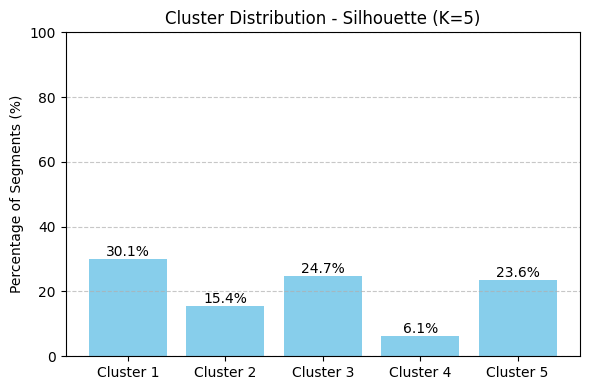

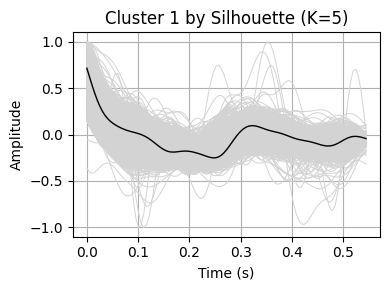

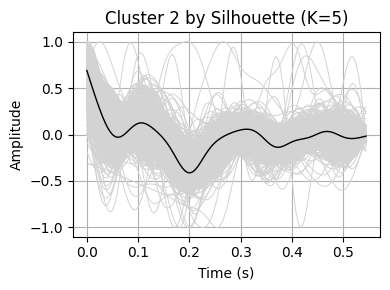

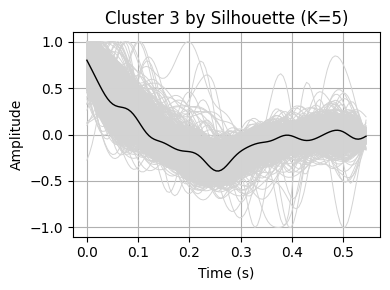

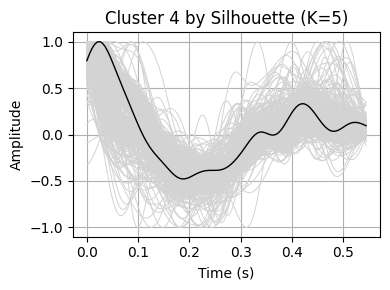

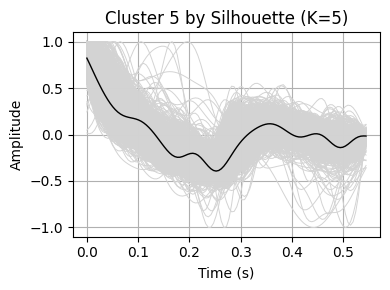


🔍 DaviesBouldin → Mejor K: 4 (valor: 2.3991)


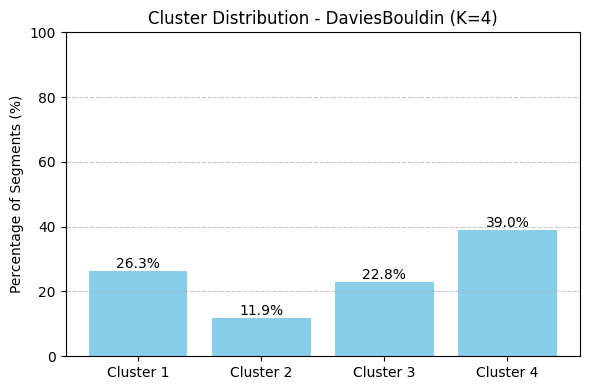

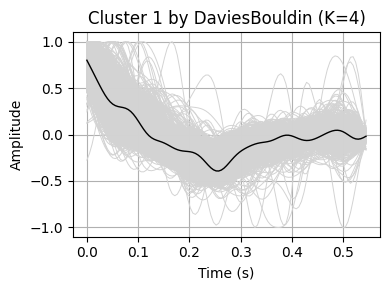

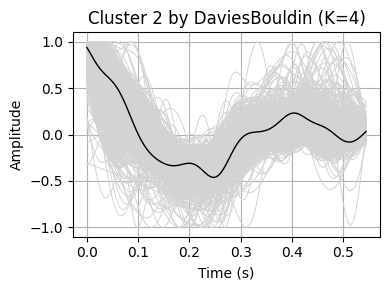

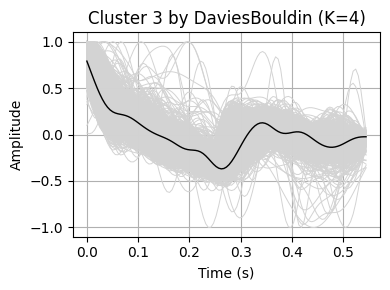

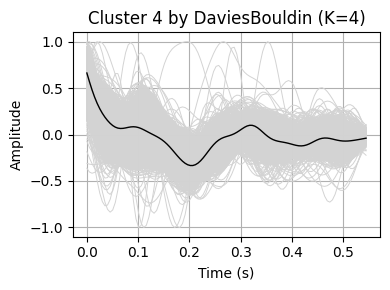


🔍 CalinskiHarabasz → Mejor K: 4 (valor: 1134.2649)


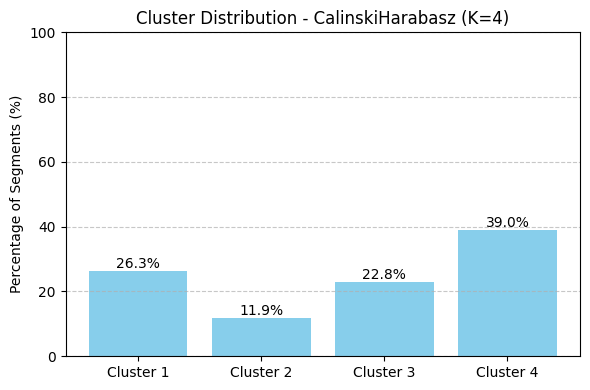

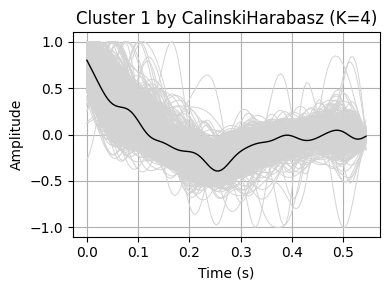

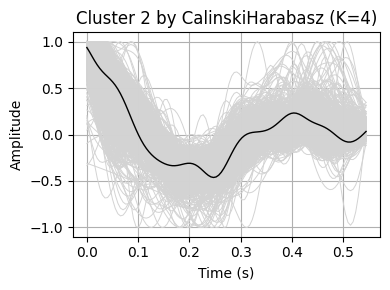

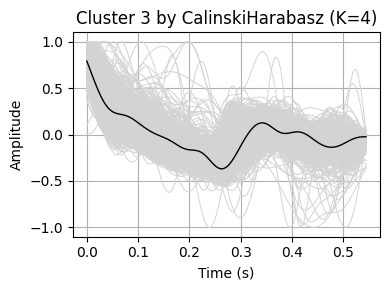

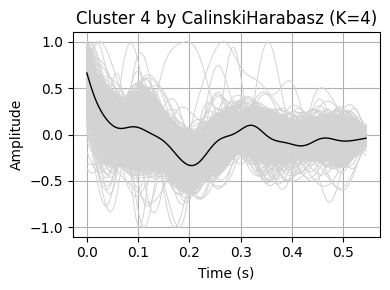


🔍 Dunn → Mejor K: 5 (valor: 0.0182)


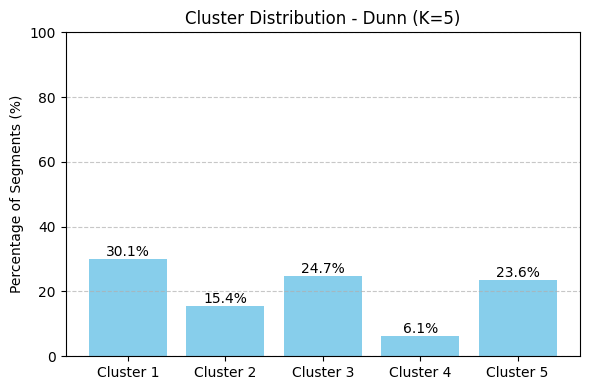

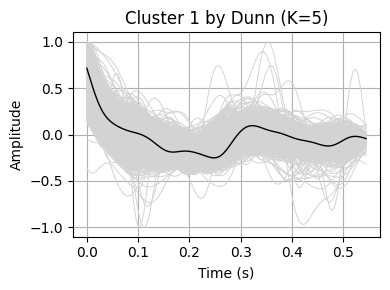

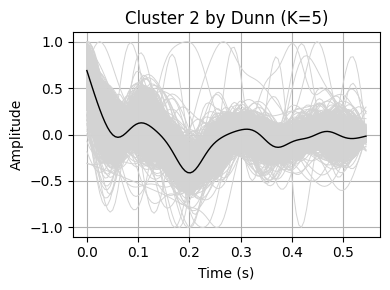

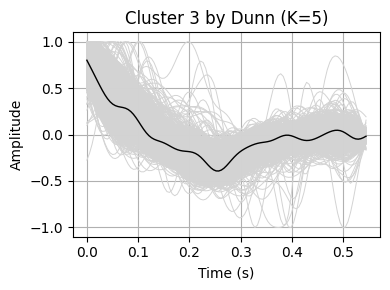

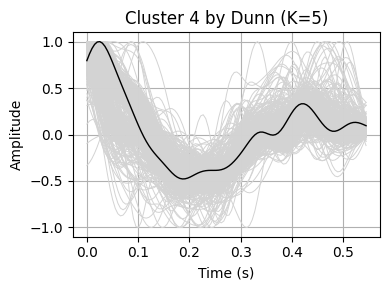

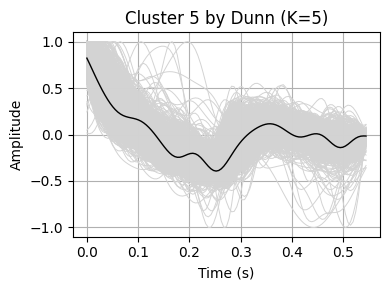

In [29]:
# === Clustering ===
range_k = range(4, 6)
results = []

for k in range_k:
    print(f"\n🔢 K = {k}")
    initial_medoids = random.sample(range(len(X)), k)
    kmed = kmedoids(dtw_distances.tolist(), initial_medoids, data_type='distance_matrix')
    kmed.process()
    clusters = kmed.get_clusters()

    labels = np.empty(len(X), dtype=int)
    for idx, points in enumerate(clusters):
        labels[points] = idx

    silhouette = silhouette_score(dtw_distances, labels, metric='precomputed')
    davies = davies_bouldin_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    dunn = dunn_index(X, labels)

    results.append({
        'K': k,
        'Silhouette': silhouette,
        'DaviesBouldin': davies,
        'CalinskiHarabasz': calinski,
        'Dunn': dunn,
        'Labels': labels.copy()
    })

# === Evaluación ===
df_results = pd.DataFrame(results)
best_by = {
    'Silhouette': df_results.loc[df_results['Silhouette'].idxmax()],
    'DaviesBouldin': df_results.loc[df_results['DaviesBouldin'].idxmin()],
    'CalinskiHarabasz': df_results.loc[df_results['CalinskiHarabasz'].idxmax()],
    'Dunn': df_results.loc[df_results['Dunn'].idxmax()]
}

# === Visualización ===
fs = 198.47
t = np.arange(X.shape[1]) / fs

for metric, res in best_by.items():
    print(f"\n🔍 {metric} → Mejor K: {res['K']} (valor: {res[metric]:.4f})")
    labels = res['Labels']
    v_segments_sample[f'Cluster_{metric}'] = labels

    cluster_ids, counts = np.unique(labels, return_counts=True)
    percentages = 100 * counts / len(labels)

    # Distribución de clusters
    plt.figure(figsize=(6, 4))
    bars = plt.bar([f"Cluster {i+1}" for i in cluster_ids], percentages, color='skyblue')
    plt.ylabel("Percentage of Segments (%)")
    plt.title(f"Cluster Distribution - {metric} (K={int(res['K'])})")
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for bar, pct in zip(bars, percentages):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{pct:.1f}%", ha='center')
    plt.tight_layout()
    plt.show()

    # Morfologías
    for cluster_id in cluster_ids:
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_segments = X[cluster_indices]

        dist_submatrix = dtw_distances[np.ix_(cluster_indices, cluster_indices)]
        medoid_idx_within_cluster = np.argmin(dist_submatrix.sum(axis=1))
        medoid_idx = cluster_indices[medoid_idx_within_cluster]
        representative_segment = X[medoid_idx]

        plt.figure(figsize=(4, 3))
        for segment in cluster_segments:
            plt.plot(t, segment, color='lightgray', linewidth=0.7)
        plt.plot(t, representative_segment, color='black', linewidth=1)
        plt.title(f'Cluster {cluster_id+1} by {metric} (K={int(res["K"])})')
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


####Second senario: with this algorithm we obtain the optim number of clusters according to the elbow rule

Next, I’m going to approach it from a different perspective, as I’m not quite sure how to interpret the results I’m getting. I believe this partly depends on how I remove the U segments. But I also don’t understand the variability, since sometimes the Silhouette parameter suggests K=2 and other times K=6.

So now, I’m going to apply this clustering method for different predefined K values. For each of these K values, I will generate plots showing the grouped segments, and I will calculate the average intra-cluster distance using the DTW distance matrix, which provides a metric of morphological homogeneity for each clustering. Then, I will apply the elbow method to determine the optimal number of clusters.

Once the clustering techniques have been applied to the partial segment and the optimal K has been found, the next step is to store the full segment in a table following this structure: as many columns as distinct clusters detected (e.g., 4 columns if 4 clusters were found because the optimal K is 4), and as many rows as different segments in each cluster.

Cargando matriz de distancias DTW desde archivo...
Probando diferentes valores de K...
 - Clustering with K = 2


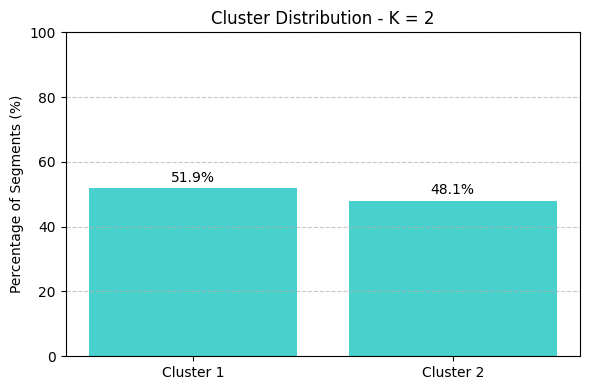

   → Medium Distance intra-cluster: 0.9785


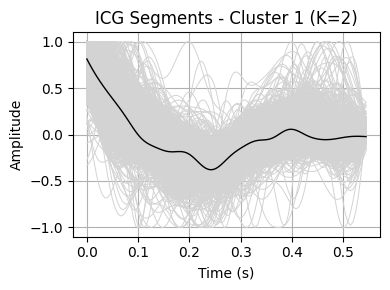

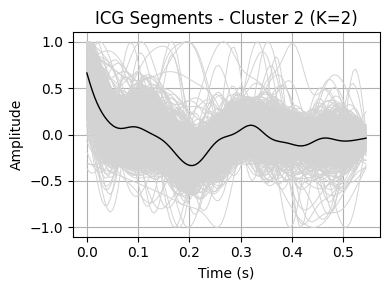

 - Clustering with K = 3


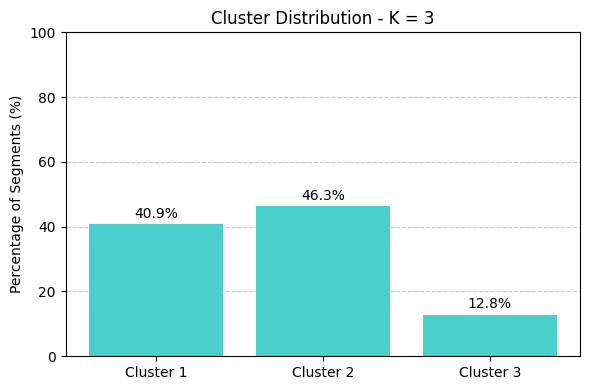

   → Medium Distance intra-cluster: 0.9864


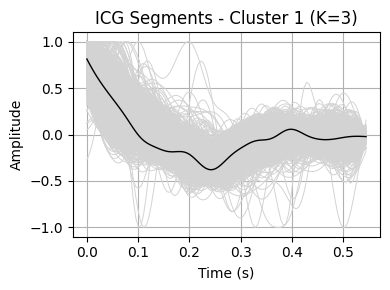

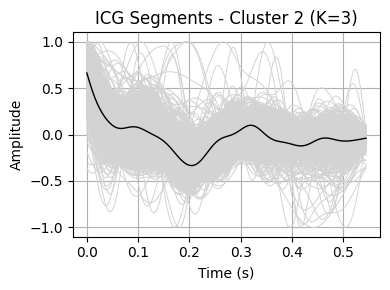

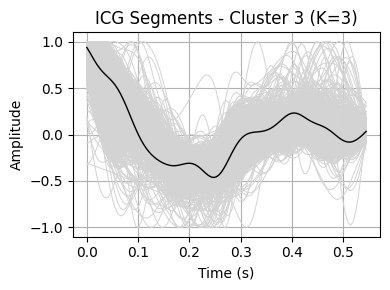

 - Clustering with K = 4


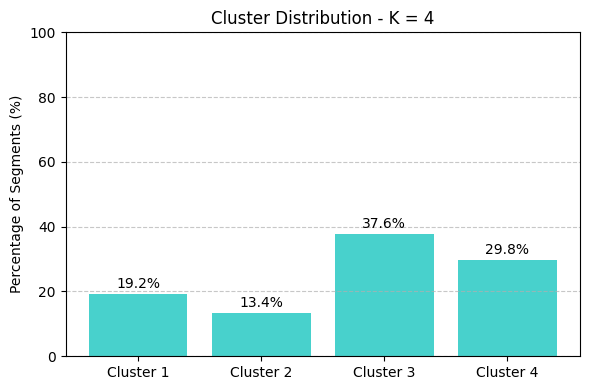

   → Medium Distance intra-cluster: 0.9205


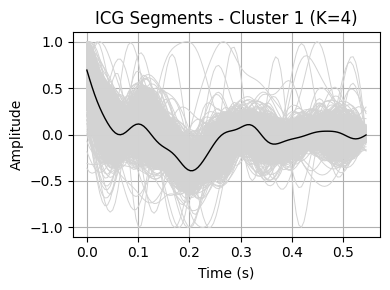

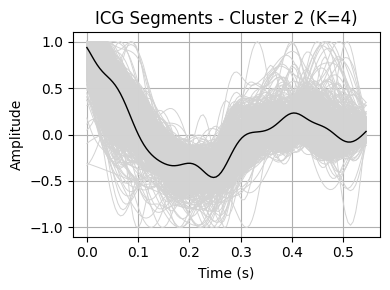

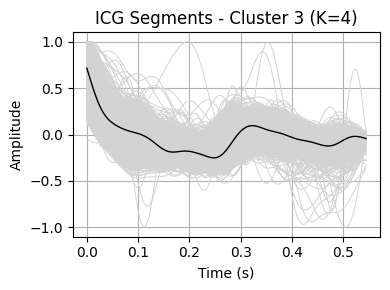

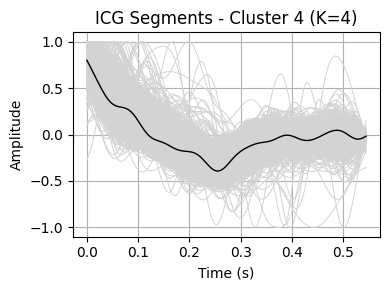

 - Clustering with K = 5


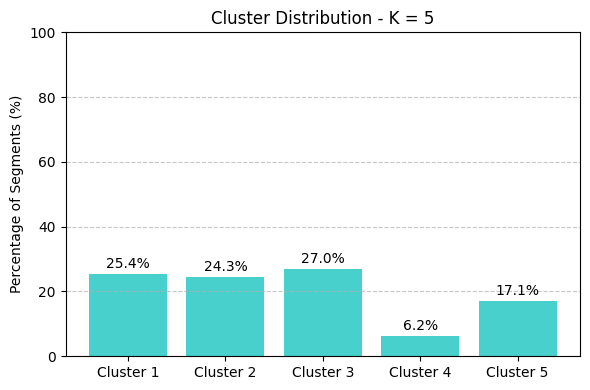

   → Medium Distance intra-cluster: 0.8536


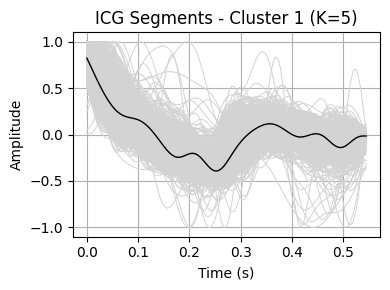

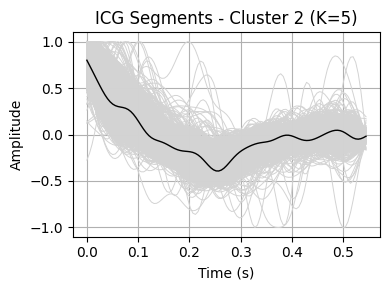

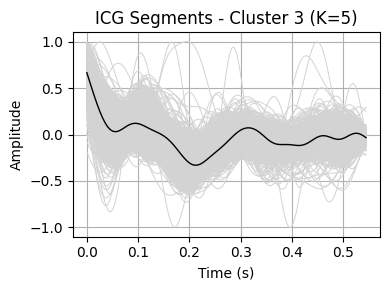

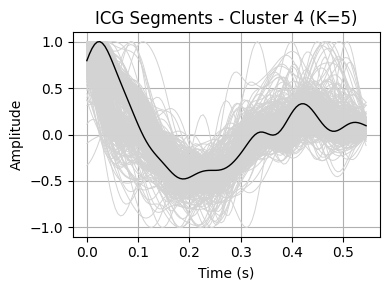

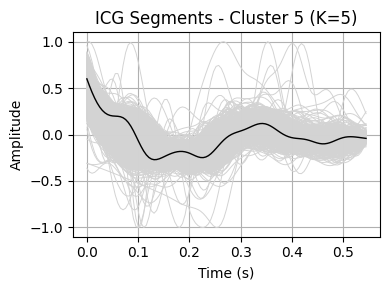

 - Clustering with K = 6


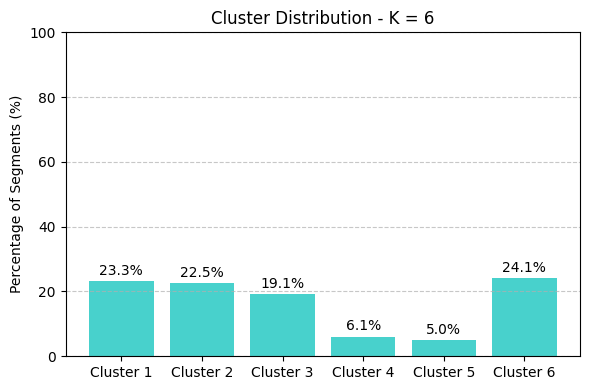

   → Medium Distance intra-cluster: 0.8688


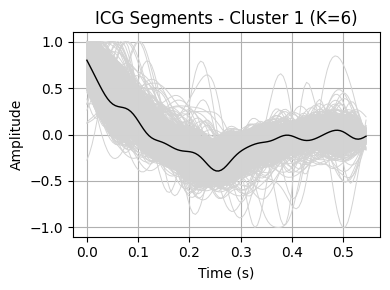

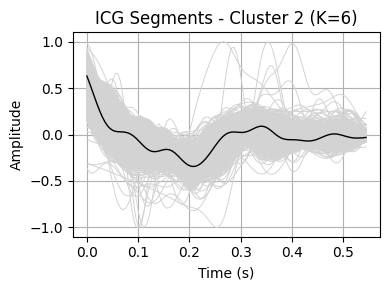

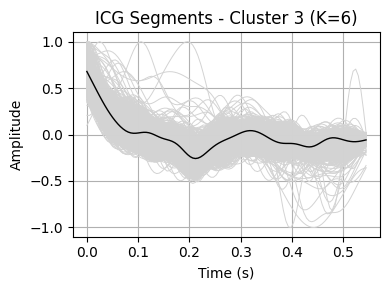

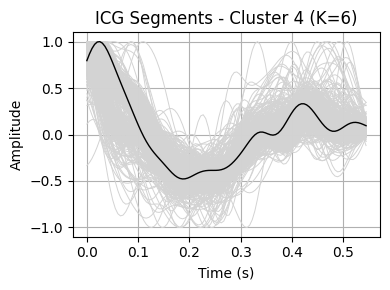

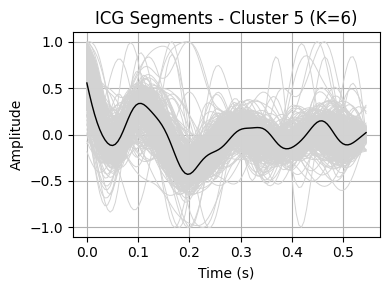

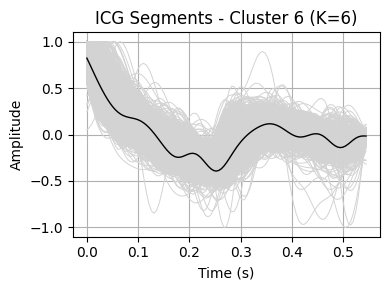

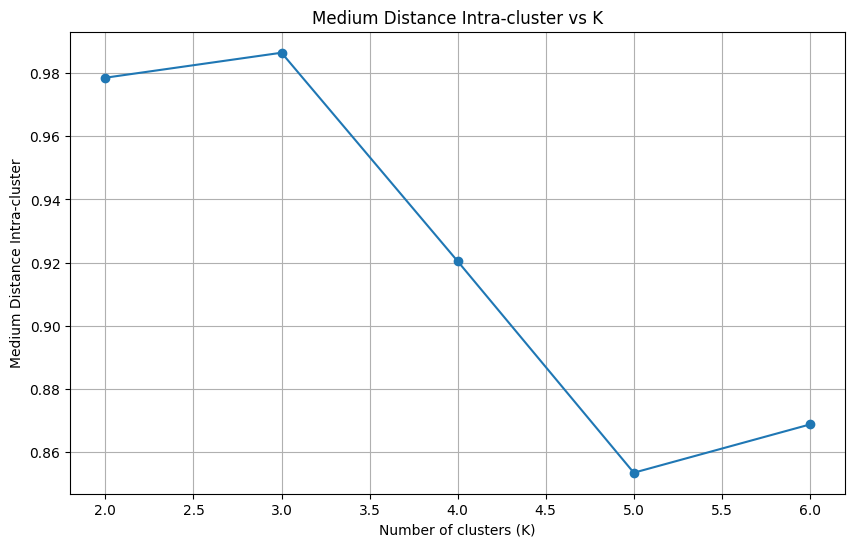

In [30]:

# 2. CARGAR la matriz de distancias DTW
print("Cargando matriz de distancias DTW desde archivo...")
dtw_distances = np.load(dtw_matrix_filename)


# 3. Función para calcular distancia promedio intra-cluster
def intra_cluster_distance(k, labels, dtw_distances):
    intra_cluster_distances = []

    for cluster_id in range(k):
        cluster_points = np.where(labels == cluster_id)[0]
        if len(cluster_points) > 1:
            # Calcular la distancia promedio entre todos los pares de segmentos dentro del cluster
            distances = dtw_distances[cluster_points[:, None], cluster_points]
            intra_cluster_distances.append(np.mean(distances))  # Promedio de las distancias DTW dentro del cluster
        else:
            intra_cluster_distances.append(0)  # Si solo hay un elemento en el cluster, la distancia es 0

    return np.mean(intra_cluster_distances)  # Promedio de todas las distancias intra-cluster para este K

# 4. Probar distintos valores de K (2 a 6)
intra_cluster_distances_per_k = {}

print("Probando diferentes valores de K...")
for k in range(2, 7):
    print(f" - Clustering with K = {k}")

    # Elegir k índices aleatorios como medoids iniciales
    initial_medoids = random.sample(range(len(X)), k)

    # Crear e inicializar el algoritmo con matriz de distancias
    kmedoids_instance = kmedoids(dtw_distances.tolist(), initial_medoids, data_type='distance_matrix')

    # Ejecutar el clustering
    kmedoids_instance.process()

    # Obtener los clusters
    clusters = kmedoids_instance.get_clusters()

    # Crear array de etiquetas
    labels = np.empty(len(X), dtype=int)
    for cluster_id, cluster_points in enumerate(clusters):
        labels[cluster_points] = cluster_id

    #Distribution of each cluster
    cluster_ids, counts = np.unique(labels, return_counts=True)
    total = len(labels)
    percentages = 100 * counts / total

    plt.figure(figsize=(6, 4))
    bars = plt.bar([f"Cluster {i+1}" for i in cluster_ids], percentages, color='mediumturquoise')
    plt.ylabel("Percentage of Segments (%)")
    plt.title(f"Cluster Distribution - K = {k}")
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for bar, pct in zip(bars, percentages):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{pct:.1f}%", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()


    # Evaluar la distancia promedio intra-cluster
    mean_intra_cluster_distance = intra_cluster_distance(k, labels, dtw_distances)
    intra_cluster_distances_per_k[k] = mean_intra_cluster_distance
    print(f"   → Medium Distance intra-cluster: {mean_intra_cluster_distance:.4f}")

    # Crear los plots de los clusters con mejoras visuales
    # Crear los plots de los clusters con mejoras visuales
    t = np.arange(X.shape[1]) / fs
    for cluster_id in range(k):
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_segments = X[cluster_indices]

        if cluster_segments.shape[0] == 0:
            continue  # Evitar clusters vacíos

        # Extraer la submatriz de distancias DTW entre los segmentos de este cluster
        dist_submatrix = dtw_distances[np.ix_(cluster_indices, cluster_indices)]

        # Sumar distancias de cada segmento al resto para encontrar el medoid
        sum_distances = dist_submatrix.sum(axis=1)
        medoid_idx_within_cluster = np.argmin(sum_distances)
        medoid_idx = cluster_indices[medoid_idx_within_cluster]

        # Segmento representativo = medoid (segmento real dentro del cluster)
        representative_segment = X[medoid_idx]

        plt.figure(figsize=(4, 3))

        # Dibujar todos los segmentos en gris claro
        for segment in cluster_segments:
            plt.plot(t, segment, color='lightgray', linewidth=0.7)

        # Dibujar el segmento representativo en azul oscuro
        plt.plot(t, representative_segment, color='black', linewidth=1)

        plt.title(f'ICG Segments - Cluster {cluster_id+1} (K={k})')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Mostrar las distancias intra-cluster para cada K
plt.figure(figsize=(10, 6))
plt.plot(list(intra_cluster_distances_per_k.keys()), list(intra_cluster_distances_per_k.values()), marker='o')
plt.title('Medium Distance Intra-cluster vs K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Medium Distance Intra-cluster')
plt.grid(True)
plt.show()


In [31]:
#Se aplica la técnica del codo para hallar K óptimo.
from kneed import KneeLocator

# Detectar punto del codo ignorando el primer salto (1 -> 2). Esto se hace porque si K se obtiene por caída más brusca evidentemente se obtiene
# que es en k=2 mientras que este puede no ser el valor óptimo.

# Extraer los valores de K y sus distancias intra-cluster
Ks = np.array(list(intra_cluster_distances_per_k.keys()))
distances = np.array(list(intra_cluster_distances_per_k.values()))

# Aplicar método del codo, ignorando el primer salto para evitar que devuelva K=2 por defecto
kneedle = KneeLocator(Ks, distances, curve='convex', direction='decreasing')

if kneedle.knee is not None:
    optimal_k = kneedle.knee
    print(f"\n✅ K optimum detected automatically with the elbow's method: K = {optimal_k}")
else:
    # Si no se detecta un codo claro, seleccionamos el mayor descenso RELATIVO excluyendo el primero
    relative_diffs = np.diff(distances) / distances[:-1]  # cambios relativos
    best_index = np.argmin(relative_diffs[1:]) + 1  # +1 porque ignoramos salto K=2
    optimal_k = Ks[best_index]
    print(f"\n⚠️ There is not a clear elbow. Selected K = {optimal_k} as the most prominent relative decrease after K=2.")

# Si quieres guardar este K óptimo para luego usarlo:
k_optimo = optimal_k

import pandas as pd

# Volver a aplicar clustering sobre la muestra con el K óptimo
print(f"\n🔁 Applying final clustering with K = {optimal_k}...")
initial_medoids = random.sample(range(len(X)), optimal_k)
final_kmedoids = kmedoids(dtw_distances.tolist(), initial_medoids, data_type='distance_matrix')
final_kmedoids.process()
final_clusters = final_kmedoids.get_clusters()

# Crear etiquetas finales
final_labels = np.empty(len(X), dtype=int)
for cluster_id, cluster_points in enumerate(final_clusters):
    final_labels[cluster_points] = cluster_id

# Crear tabla de clusters con los segmentos completos
cluster_table = pd.DataFrame(columns=[f'Cluster_{i}' for i in range(optimal_k)])

# Importante: obtener los índices originales de los segmentos muestreados
original_indices = v_segments['Segment_partial'].reset_index().iloc[:, 0].values

# Asignar los segmentos completos a la tabla por cluster
for i, label in enumerate(final_labels):
    idx = original_indices[i]  # Índice en el DataFrame original
    full_segment = v_segments.loc[idx, 'Segment']
    row = [None] * optimal_k
    row[label] = full_segment
    cluster_table.loc[len(cluster_table)] = row

# Mostrar resumen
print(f"✅ Tabla de segmentos agrupados por cluster generada con {len(cluster_table)} filas.")
print(cluster_table.head())

# Guardar tabla en CSV
cluster_table.to_csv('tabla_clusters_segmentos_completos.csv', index=False)




✅ K optimum detected automatically with the elbow's method: K = 2

🔁 Applying final clustering with K = 2...
✅ Tabla de segmentos agrupados por cluster generada con 8382 filas.
                                           Cluster_0 Cluster_1
0  [-0.13888494714529273, -0.17985700400927515, -...      None
1  [-0.15441146187677, -0.1518585391166666, -0.15...      None
2  [-0.08502829553271386, -0.09067601200024869, -...      None
3  [-0.15013738778058508, -0.22562770016611056, -...      None
4  [-0.13518603926770015, -0.1208087853106023, -0...      None


The expected result is that as K increases, the distance should decrease, since there will be a greater number of clusters and therefore the segments within each cluster should be more similar. I must say that, just like before, the results vary with each run. Sometimes the lowest distance corresponds to K=6, other times to K=5...


In this code, one representative segment and two random ones per cluster are selected and plotted, based on the results of the clustering performed on the 1000 segments.

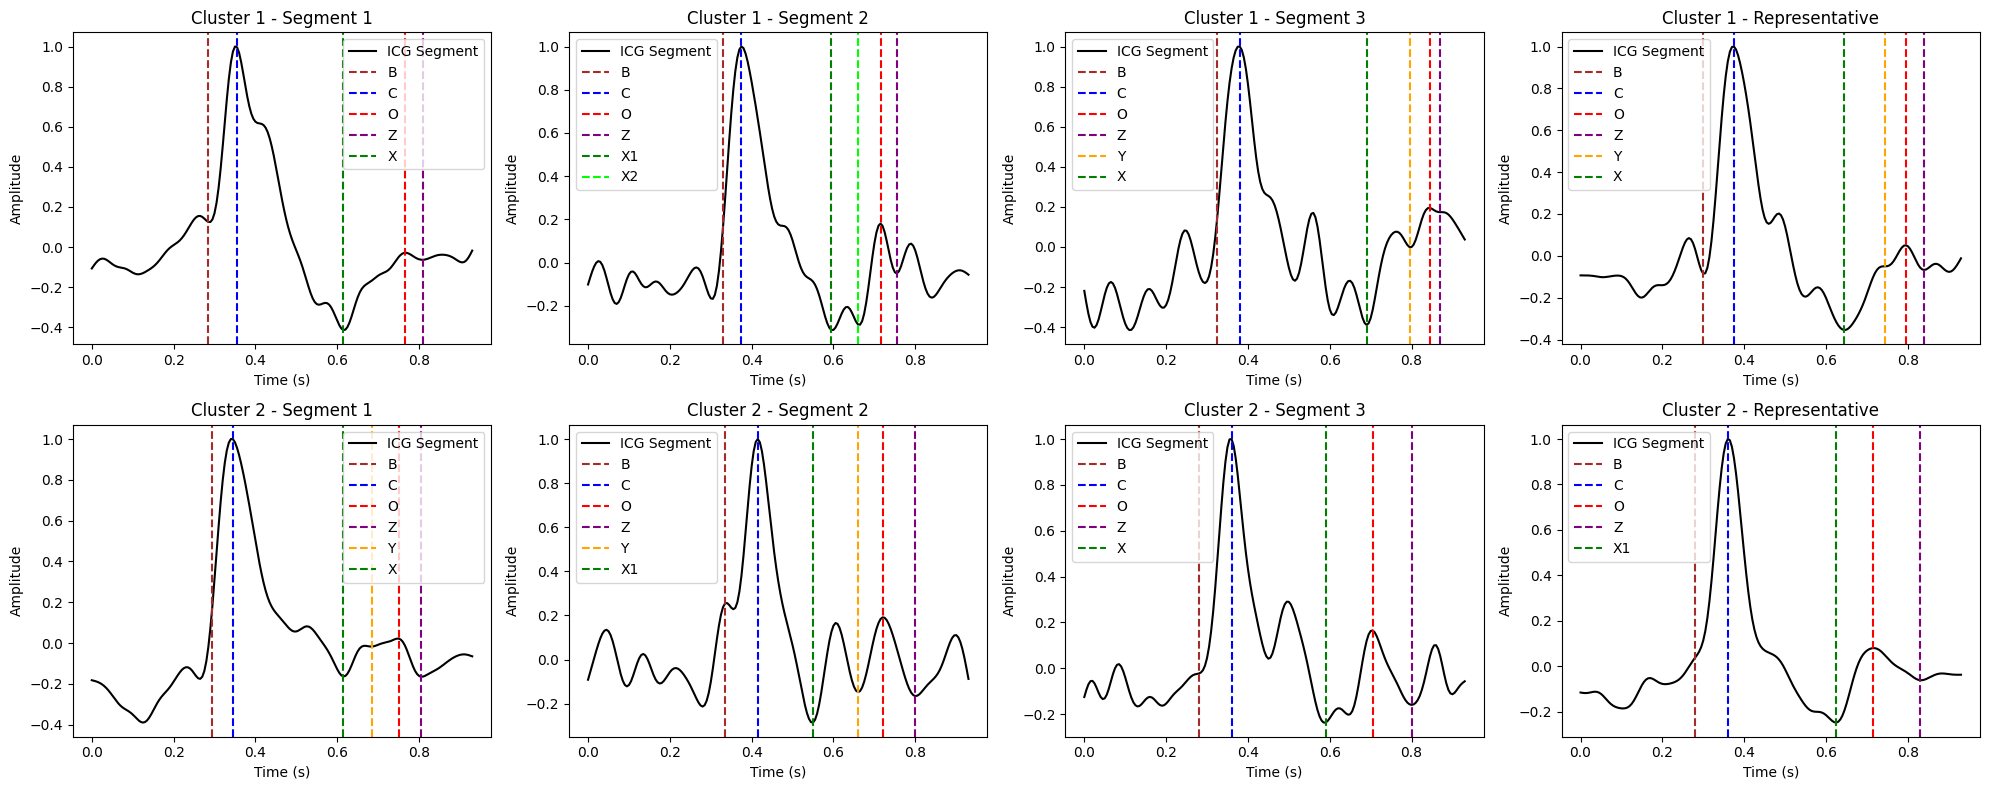

In [32]:
N = 3  # Número de segmentos a visualizar por cluster
fs = 200  # Frecuencia de muestreo

def plot_segment_with_points(ax, segment, points, fs, title=""):
    t = np.arange(len(segment)) / fs  # Vector de tiempo en segundos
    ax.plot(t, segment, label='ICG Segment', color='black')
    colors = {
        "B": "brown", "C": "blue", "X": "green", "X1": "green", "X2": "lime",
        "O": "red", "Z": "purple", "Y": "orange"
    }
    for label, index in points.items():
        if index is not None:
            ax.axvline(index / fs, color=colors.get(label, 'black'), linestyle='--', label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

def calculate_medoid_segment(segments):
    min_len = min(len(s) for s in segments)
    trimmed_segments = [s[:min_len] for s in segments]
    n = len(trimmed_segments)

    # Matriz de distancias
    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(trimmed_segments[i] - trimmed_segments[j])
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist

    # Suma de distancias para cada segmento
    dist_sums = dist_matrix.sum(axis=1)

    # Índice del médoid (menor suma de distancias)
    medoid_idx = np.argmin(dist_sums)

    return trimmed_segments[medoid_idx]

num_clusters = k_optimo
fig, axes = plt.subplots(num_clusters, N + 1, figsize=(5 * (N + 1), 4 * num_clusters))

for cluster_id in range(num_clusters):
    # Extraer todos los segmentos del cluster actual, eliminando valores nulos
    segments = cluster_table[f'Cluster_{cluster_id}'].dropna().tolist()

    if len(segments) == 0:
        print(f"⚠️ Cluster {cluster_id} vacío.")
        continue

    # Seleccionar N segmentos aleatorios
    random.seed()
    selected_segments = random.sample(segments, min(N, len(segments)))

    # Calcular el segmento representativo
    representative_segment = calculate_medoid_segment(segments)

    # Detectar puntos característicos en el segmento representativo
    C_peaks, _ = detect_C_peaks(representative_segment, fs)
    if len(C_peaks) == 0:
        print(f"⚠️ Cluster {cluster_id}: no se detectó pico C en el segmento representativo.")
        continue
    C_index = C_peaks[0]
    B_index = find_B_point(representative_segment, C_index, fs)
    resultado_X = detectar_punto_X(representative_segment, C_index, fs)
    O_index = detect_O_point(representative_segment, C_index, fs)
    Z_index = detect_Z_point(representative_segment, O_index, fs) if O_index else None
    Y_index = detectar_punto_Y(representative_segment, resultado_X, O_index, fs)

    puntos_repr = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
    if resultado_X["caso"] == "X":
        puntos_repr["X"] = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        puntos_repr["X1"] = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        puntos_repr["X1"] = resultado_X["X1"]
        puntos_repr["X2"] = resultado_X["X2"]

    # Plot de segmentos individuales
    for i, segment in enumerate(selected_segments):
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            print(f"⚠️ Segmento en Cluster {cluster_id}: sin pico C.")
            continue
        C_index = C_peaks[0]
        B_index = find_B_point(segment, C_index, fs)
        resultado_X = detectar_punto_X(segment, C_index, fs)
        O_index = detect_O_point(segment, C_index, fs)
        Z_index = detect_Z_point(segment, O_index, fs) if O_index else None
        Y_index = detectar_punto_Y(segment, resultado_X, O_index, fs)

        puntos = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
        if resultado_X["caso"] == "X":
            puntos["X"] = resultado_X["X"]
        elif resultado_X["caso"] == "X1":
            puntos["X1"] = resultado_X["X1"]
        elif resultado_X["caso"] == "X1_X2":
            puntos["X1"] = resultado_X["X1"]
            puntos["X2"] = resultado_X["X2"]

        plot_segment_with_points(axes[cluster_id, i], segment, puntos, fs, title=f"Cluster {cluster_id+1} - Segment {i+1}")

    # Plot del segmento representativo
    plot_segment_with_points(axes[cluster_id, N], representative_segment, puntos_repr, fs, title=f"Cluster {cluster_id+1} - Representative")

plt.tight_layout()
plt.show()


####Third scenario: we put the K that we consider

In [29]:
# 🔧 Define aquí el K manual deseado
k_manual = 5

print(f"\n🔁 Aplicando clustering manual con K = {k_manual}...")

# Aplica clustering con K manual
initial_medoids_manual = random.sample(range(len(X)), k_manual)
kmedoids_manual = kmedoids(dtw_distances.tolist(), initial_medoids_manual, data_type='distance_matrix')
kmedoids_manual.process()
clusters_manual = kmedoids_manual.get_clusters()

# Crear etiquetas manuales
labels_manual = np.empty(len(X), dtype=int)
for cluster_id, cluster_points in enumerate(clusters_manual):
    labels_manual[cluster_points] = cluster_id

# Crear tabla de clusters con los segmentos completos para K manual
cluster_table_manual = pd.DataFrame(columns=[f'Cluster_{i}' for i in range(k_manual)])

# Índices reales
original_indices = v_segments.index

# Asignar los segmentos completos a la tabla por cluster
for i, label in enumerate(labels_manual):
    idx = original_indices[i]
    full_segment = v_segments.loc[idx, 'Segment']
    row = [None] * k_manual
    row[label] = full_segment
    cluster_table_manual.loc[len(cluster_table_manual)] = row

# Mostrar resumen
print(f"✅ Tabla para K = {k_manual} generada con {len(cluster_table_manual)} filas.")
print(cluster_table_manual.head())

# Guardar en CSV con nombre personalizado
cluster_table_manual.to_csv(f'tabla_clusters_segmentos_completos_K{k_manual}.csv', index=False)



🔁 Aplicando clustering manual con K = 5...
✅ Tabla para K = 5 generada con 8382 filas.
  Cluster_0 Cluster_1 Cluster_2  \
0      None      None      None   
1      None      None      None   
2      None      None      None   
3      None      None      None   
4      None      None      None   

                                           Cluster_3  \
0                                               None   
1                                               None   
2  [-0.08502829553271386, -0.09067601200024869, -...   
3                                               None   
4                                               None   

                                           Cluster_4  
0  [-0.13888494714529273, -0.17985700400927515, -...  
1  [-0.15441146187677, -0.1518585391166666, -0.15...  
2                                               None  
3  [-0.15013738778058508, -0.22562770016611056, -...  
4  [-0.13518603926770015, -0.1208087853106023, -0...  


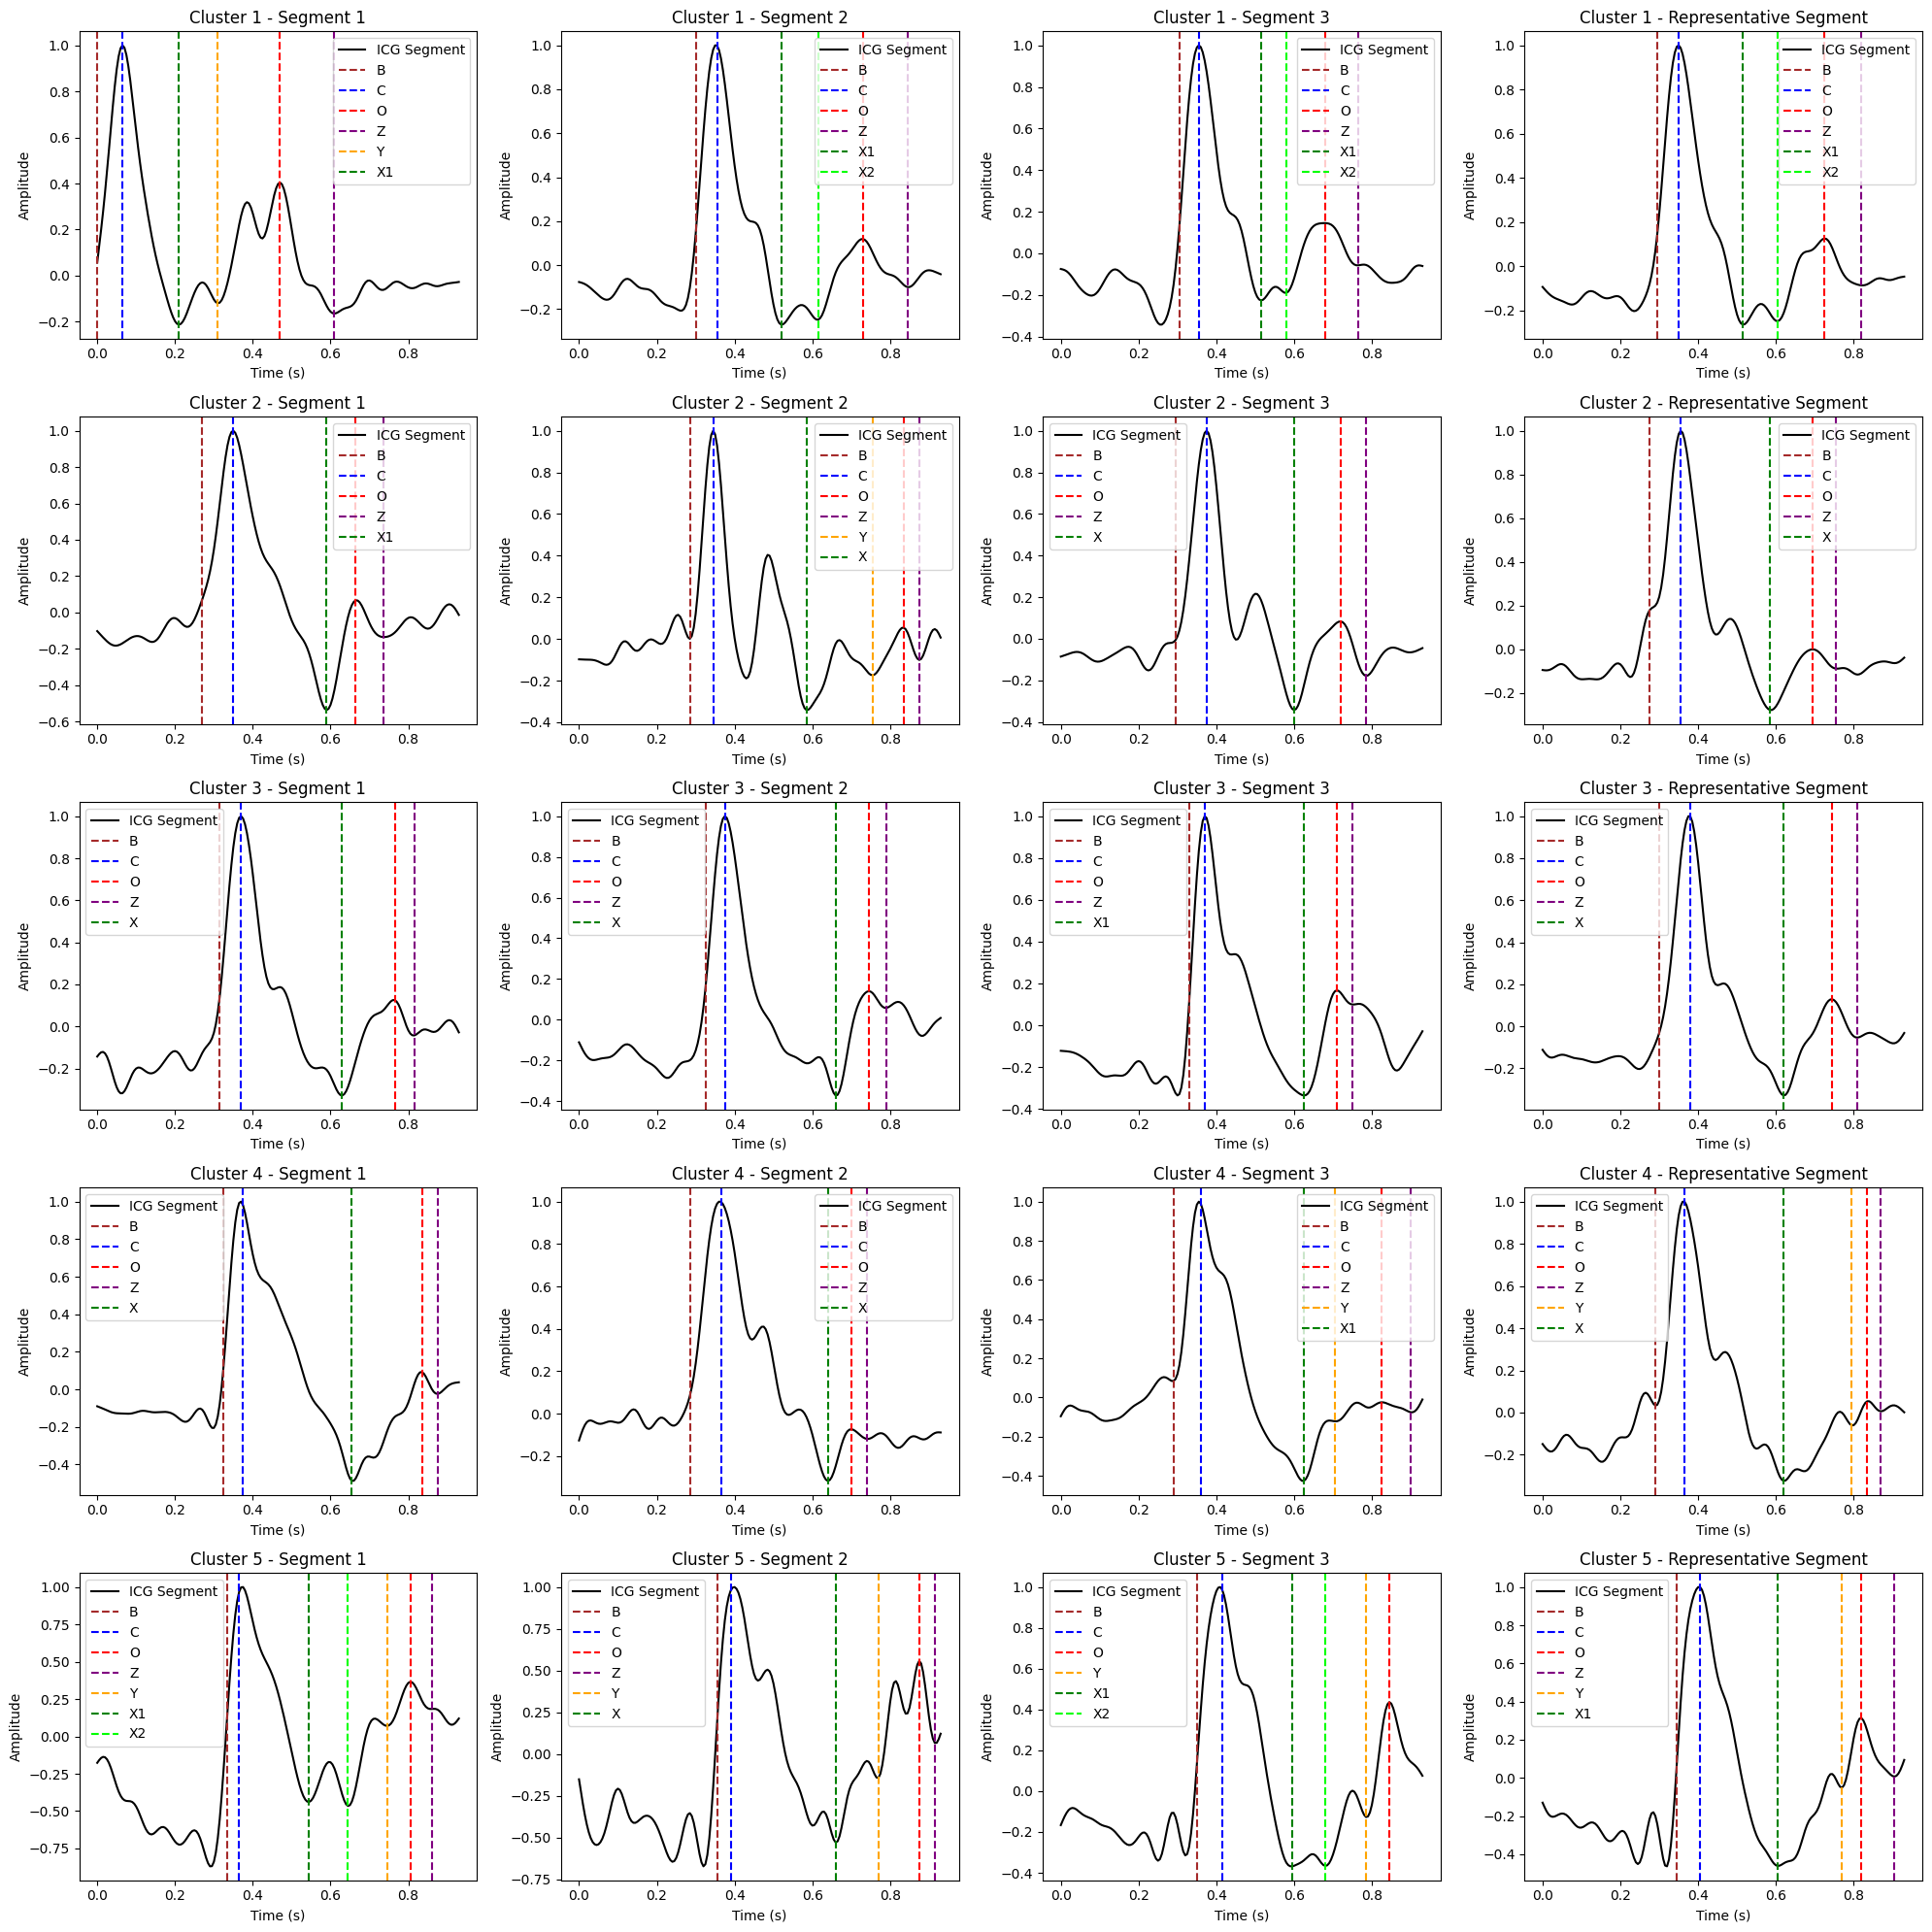

In [30]:
N = 3  # Número de segmentos a visualizar por cluster
fs = 200  # Frecuencia de muestreo

def plot_segment_with_points(ax, segment, points, fs, title=""):
    t = np.arange(len(segment)) / fs  # Vector de tiempo en segundos
    ax.plot(t, segment, label='ICG Segment', color='black')
    colors = {
        "B": "brown", "C": "blue", "X": "green", "X1": "green", "X2": "lime",
        "O": "red", "Z": "purple", "Y": "orange"
    }
    for label, index in points.items():
        if index is not None:
            ax.axvline(index / fs, color=colors.get(label, 'black'), linestyle='--', label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')


def calculate_medoid_segment(segments):
    min_len = min(len(s) for s in segments)
    trimmed_segments = [s[:min_len] for s in segments]
    n = len(trimmed_segments)

    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(trimmed_segments[i] - trimmed_segments[j])
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist

    dist_sums = dist_matrix.sum(axis=1)
    medoid_idx = np.argmin(dist_sums)

    return trimmed_segments[medoid_idx]


num_clusters = k_manual
fig, axes = plt.subplots(num_clusters, N + 1, figsize=(5 * (N + 1), 4 * num_clusters))

for cluster_id in range(num_clusters):
    # Extraer todos los segmentos del cluster actual, eliminando valores nulos
    segments = cluster_table_manual[f'Cluster_{cluster_id}'].dropna().tolist()

    if len(segments) == 0:
        print(f"⚠️ Cluster {cluster_id} vacío.")
        continue

    # Seleccionar N segmentos aleatorios
    random.seed()
    selected_segments = random.sample(segments, min(N, len(segments)))

    # Calcular el segmento representativo
    representative_segment = calculate_medoid_segment(segments)

    # Detectar puntos característicos en el segmento representativo
    C_peaks, _ = detect_C_peaks(representative_segment, fs)
    if len(C_peaks) == 0:
        print(f"⚠️ Cluster {cluster_id}: no se detectó pico C en el segmento representativo.")
        continue
    C_index = C_peaks[0]
    B_index = find_B_point(representative_segment, C_index, fs)
    resultado_X = detectar_punto_X(representative_segment, C_index, fs)
    O_index = detect_O_point(representative_segment, C_index, fs)
    Z_index = detect_Z_point(representative_segment, O_index, fs) if O_index else None
    Y_index = detectar_punto_Y(representative_segment, resultado_X, O_index, fs)

    puntos_repr = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
    if resultado_X["caso"] == "X":
        puntos_repr["X"] = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        puntos_repr["X1"] = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        puntos_repr["X1"] = resultado_X["X1"]
        puntos_repr["X2"] = resultado_X["X2"]

    # Plot de segmentos individuales
    for i, segment in enumerate(selected_segments):
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            print(f"⚠️ Segmento en Cluster {cluster_id}: sin pico C.")
            continue
        C_index = C_peaks[0]
        B_index = find_B_point(segment, C_index, fs)
        resultado_X = detectar_punto_X(segment, C_index, fs)
        O_index = detect_O_point(segment, C_index, fs)
        Z_index = detect_Z_point(segment, O_index, fs) if O_index else None
        Y_index = detectar_punto_Y(segment, resultado_X, O_index, fs)

        puntos = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
        if resultado_X["caso"] == "X":
            puntos["X"] = resultado_X["X"]
        elif resultado_X["caso"] == "X1":
            puntos["X1"] = resultado_X["X1"]
        elif resultado_X["caso"] == "X1_X2":
            puntos["X1"] = resultado_X["X1"]
            puntos["X2"] = resultado_X["X2"]

        plot_segment_with_points(axes[cluster_id, i], segment, puntos, fs, title=f"Cluster {cluster_id+1} - Segment {i+1}")

    # Plot del segmento representativo
    plot_segment_with_points(axes[cluster_id, N], representative_segment, puntos_repr, fs, title=f"Cluster {cluster_id+1} - Representative Segment")

plt.tight_layout()
plt.show()


In [31]:
# 🔧 Define aquí el K manual deseado
k_manual = 4

print(f"\n🔁 Aplicando clustering manual con K = {k_manual}...")

# Aplica clustering con K manual
initial_medoids_manual = random.sample(range(len(X)), k_manual)
kmedoids_manual = kmedoids(dtw_distances.tolist(), initial_medoids_manual, data_type='distance_matrix')
kmedoids_manual.process()
clusters_manual = kmedoids_manual.get_clusters()

# Crear etiquetas manuales
labels_manual = np.empty(len(X), dtype=int)
for cluster_id, cluster_points in enumerate(clusters_manual):
    labels_manual[cluster_points] = cluster_id

# Crear tabla de clusters con los segmentos completos para K manual
cluster_table_manual = pd.DataFrame(columns=[f'Cluster_{i}' for i in range(k_manual)])

# Índices reales
original_indices = v_segments.index

# Asignar los segmentos completos a la tabla por cluster
for i, label in enumerate(labels_manual):
    idx = original_indices[i]
    full_segment = v_segments.loc[idx, 'Segment']
    row = [None] * k_manual
    row[label] = full_segment
    cluster_table_manual.loc[len(cluster_table_manual)] = row

# Mostrar resumen
print(f"✅ Tabla para K = {k_manual} generada con {len(cluster_table_manual)} filas.")
print(cluster_table_manual.head())

# Guardar en CSV con nombre personalizado
cluster_table_manual.to_csv(f'tabla_clusters_segmentos_completos_K{k_manual}.csv', index=False)



🔁 Aplicando clustering manual con K = 4...
✅ Tabla para K = 4 generada con 8382 filas.
  Cluster_0 Cluster_1                                          Cluster_2  \
0      None      None  [-0.13888494714529273, -0.17985700400927515, -...   
1      None      None  [-0.15441146187677, -0.1518585391166666, -0.15...   
2      None      None                                               None   
3      None      None  [-0.15013738778058508, -0.22562770016611056, -...   
4      None      None  [-0.13518603926770015, -0.1208087853106023, -0...   

                                           Cluster_3  
0                                               None  
1                                               None  
2  [-0.08502829553271386, -0.09067601200024869, -...  
3                                               None  
4                                               None  


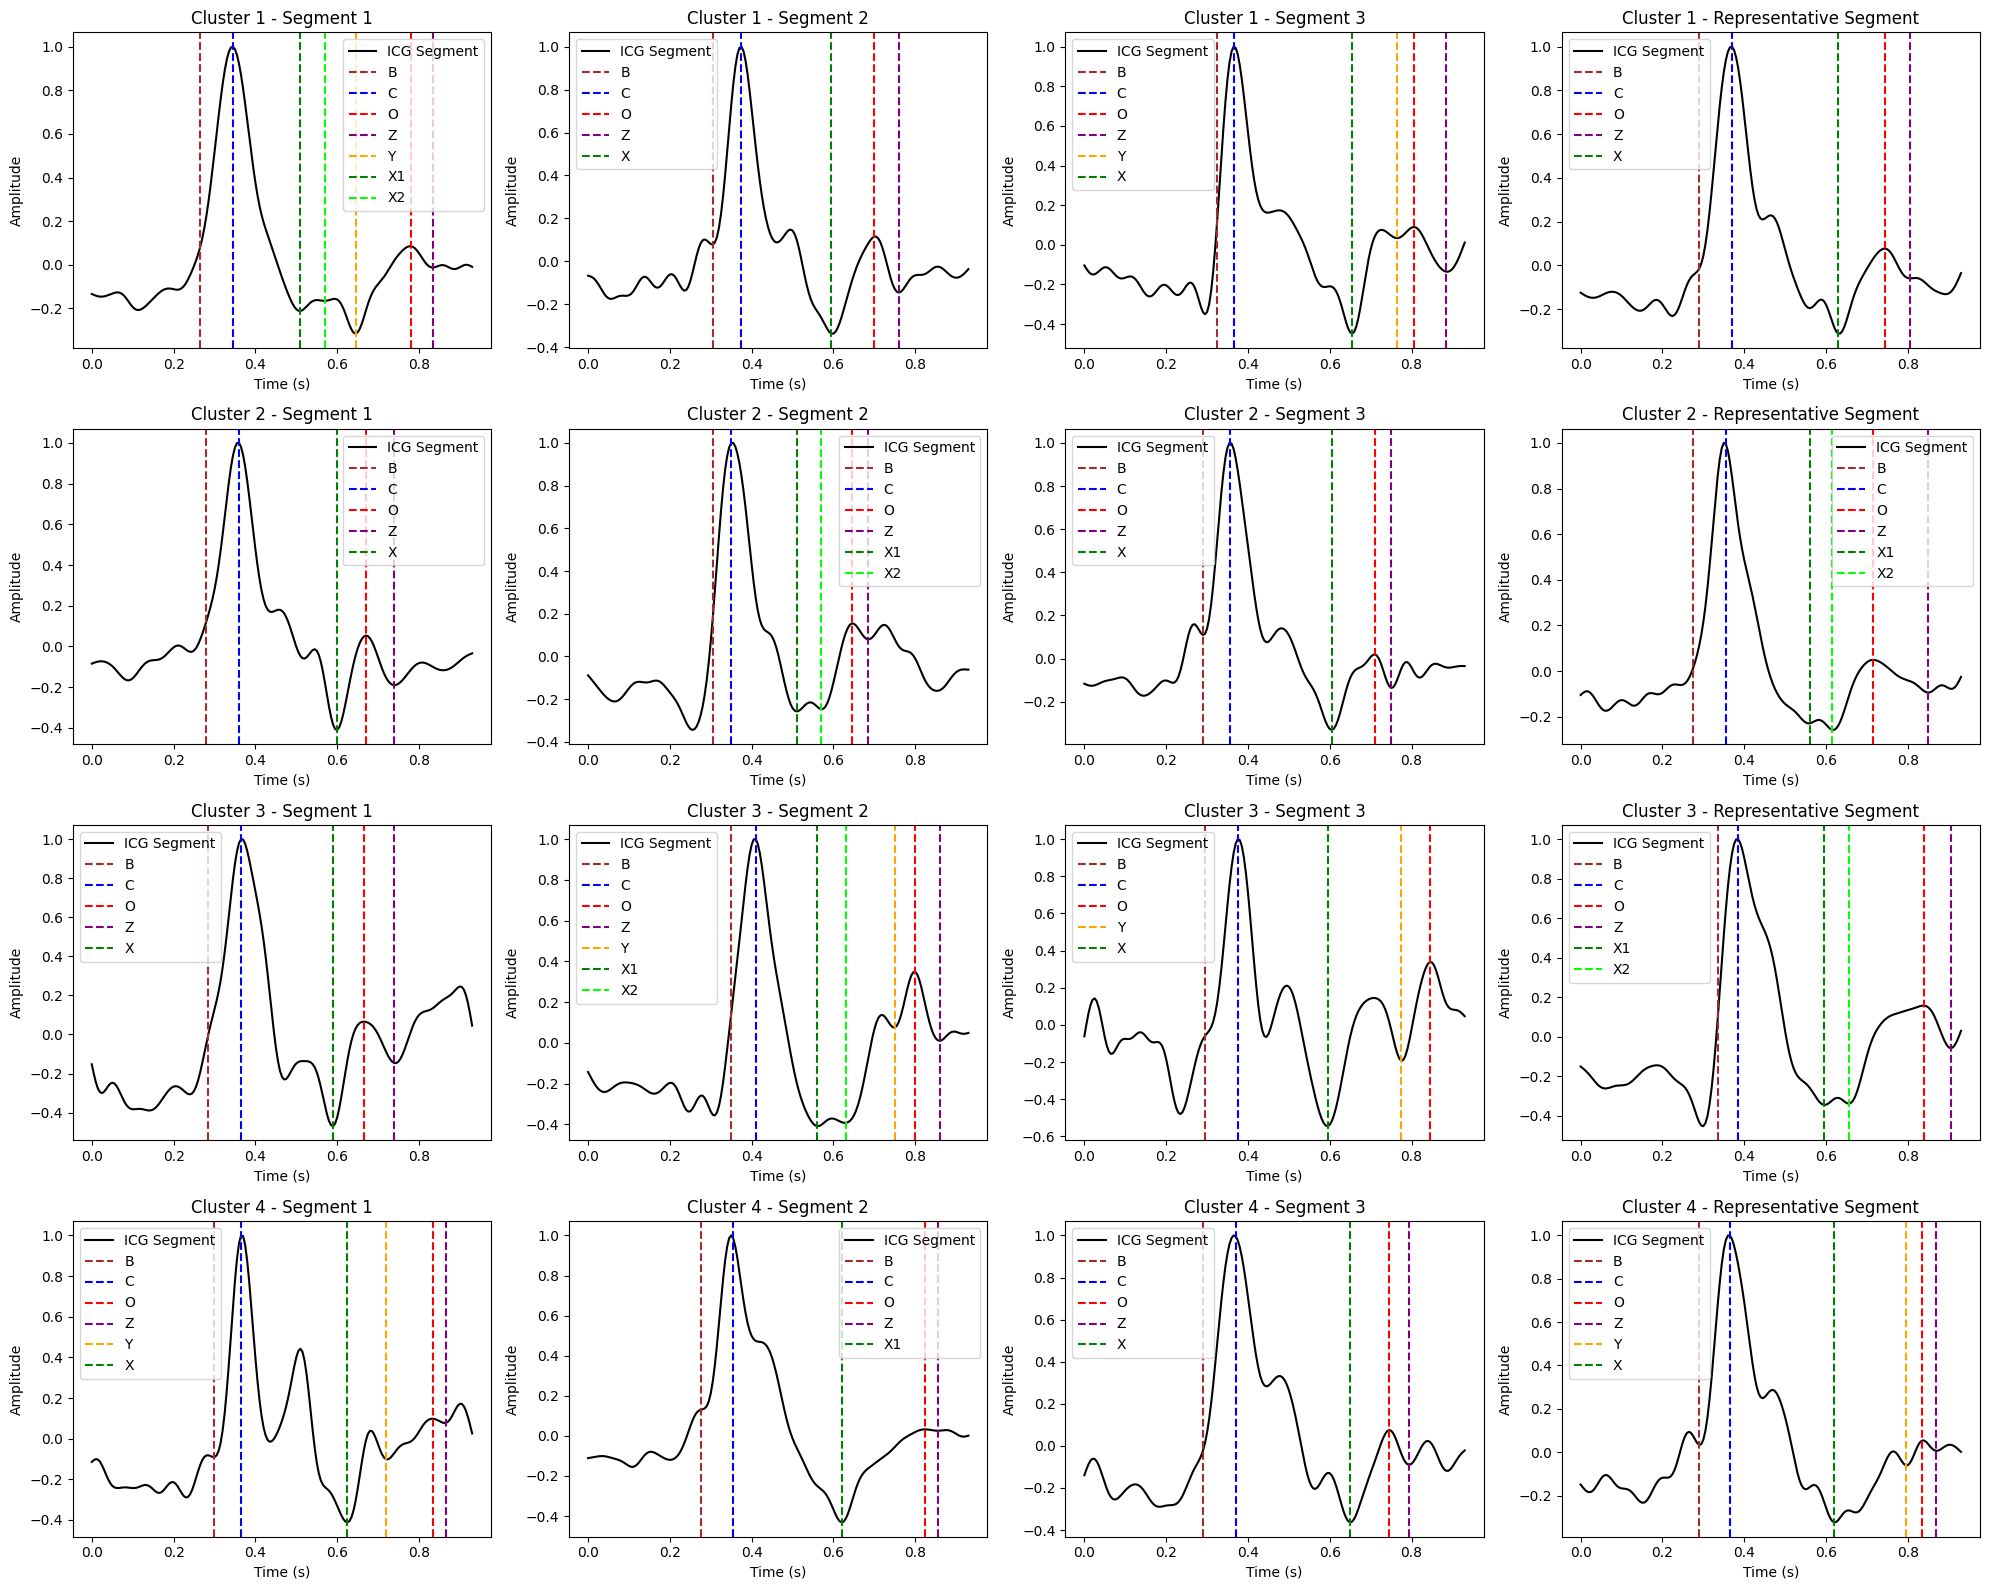

In [32]:
N = 3  # Número de segmentos a visualizar por cluster
fs = 200  # Frecuencia de muestreo

def plot_segment_with_points(ax, segment, points, fs, title=""):
    t = np.arange(len(segment)) / fs  # Vector de tiempo en segundos
    ax.plot(t, segment, label='ICG Segment', color='black')
    colors = {
        "B": "brown", "C": "blue", "X": "green", "X1": "green", "X2": "lime",
        "O": "red", "Z": "purple", "Y": "orange"
    }
    for label, index in points.items():
        if index is not None:
            ax.axvline(index / fs, color=colors.get(label, 'black'), linestyle='--', label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')


def calculate_medoid_segment(segments):
    min_len = min(len(s) for s in segments)
    trimmed_segments = [s[:min_len] for s in segments]
    n = len(trimmed_segments)

    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(trimmed_segments[i] - trimmed_segments[j])
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist

    dist_sums = dist_matrix.sum(axis=1)
    medoid_idx = np.argmin(dist_sums)

    return trimmed_segments[medoid_idx]


num_clusters = k_manual
fig, axes = plt.subplots(num_clusters, N + 1, figsize=(5 * (N + 1), 4 * num_clusters))

for cluster_id in range(num_clusters):
    # Extraer todos los segmentos del cluster actual, eliminando valores nulos
    segments = cluster_table_manual[f'Cluster_{cluster_id}'].dropna().tolist()

    if len(segments) == 0:
        print(f"⚠️ Cluster {cluster_id} vacío.")
        continue

    # Seleccionar N segmentos aleatorios
    random.seed()
    selected_segments = random.sample(segments, min(N, len(segments)))

    # Calcular el segmento representativo
    representative_segment = calculate_medoid_segment(segments)

    # Detectar puntos característicos en el segmento representativo
    C_peaks, _ = detect_C_peaks(representative_segment, fs)
    if len(C_peaks) == 0:
        print(f"⚠️ Cluster {cluster_id}: no se detectó pico C en el segmento representativo.")
        continue
    C_index = C_peaks[0]
    B_index = find_B_point(representative_segment, C_index, fs)
    resultado_X = detectar_punto_X(representative_segment, C_index, fs)
    O_index = detect_O_point(representative_segment, C_index, fs)
    Z_index = detect_Z_point(representative_segment, O_index, fs) if O_index else None
    Y_index = detectar_punto_Y(representative_segment, resultado_X, O_index, fs)

    puntos_repr = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
    if resultado_X["caso"] == "X":
        puntos_repr["X"] = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        puntos_repr["X1"] = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        puntos_repr["X1"] = resultado_X["X1"]
        puntos_repr["X2"] = resultado_X["X2"]

    # Plot de segmentos individuales
    for i, segment in enumerate(selected_segments):
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            print(f"⚠️ Segmento en Cluster {cluster_id}: sin pico C.")
            continue
        C_index = C_peaks[0]
        B_index = find_B_point(segment, C_index, fs)
        resultado_X = detectar_punto_X(segment, C_index, fs)
        O_index = detect_O_point(segment, C_index, fs)
        Z_index = detect_Z_point(segment, O_index, fs) if O_index else None
        Y_index = detectar_punto_Y(segment, resultado_X, O_index, fs)

        puntos = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
        if resultado_X["caso"] == "X":
            puntos["X"] = resultado_X["X"]
        elif resultado_X["caso"] == "X1":
            puntos["X1"] = resultado_X["X1"]
        elif resultado_X["caso"] == "X1_X2":
            puntos["X1"] = resultado_X["X1"]
            puntos["X2"] = resultado_X["X2"]

        plot_segment_with_points(axes[cluster_id, i], segment, puntos, fs, title=f"Cluster {cluster_id+1} - Segment {i+1}")

    # Plot del segmento representativo
    plot_segment_with_points(axes[cluster_id, N], representative_segment, puntos_repr, fs, title=f"Cluster {cluster_id+1} - Representative Segment")

plt.tight_layout()
plt.show()


In [33]:
# 🔧 Define aquí el K manual deseado
k_manual = 3

print(f"\n🔁 Aplicando clustering manual con K = {k_manual}...")

# Aplica clustering con K manual
initial_medoids_manual = random.sample(range(len(X)), k_manual)
kmedoids_manual = kmedoids(dtw_distances.tolist(), initial_medoids_manual, data_type='distance_matrix')
kmedoids_manual.process()
clusters_manual = kmedoids_manual.get_clusters()

# Crear etiquetas manuales
labels_manual = np.empty(len(X), dtype=int)
for cluster_id, cluster_points in enumerate(clusters_manual):
    labels_manual[cluster_points] = cluster_id

# Crear tabla de clusters con los segmentos completos para K manual
cluster_table_manual = pd.DataFrame(columns=[f'Cluster_{i}' for i in range(k_manual)])

# Índices reales
original_indices = v_segments.index

# Asignar los segmentos completos a la tabla por cluster
for i, label in enumerate(labels_manual):
    idx = original_indices[i]
    full_segment = v_segments.loc[idx, 'Segment']
    row = [None] * k_manual
    row[label] = full_segment
    cluster_table_manual.loc[len(cluster_table_manual)] = row

# Mostrar resumen
print(f"✅ Tabla para K = {k_manual} generada con {len(cluster_table_manual)} filas.")
print(cluster_table_manual.head())

# Guardar en CSV con nombre personalizado
cluster_table_manual.to_csv(f'tabla_clusters_segmentos_completos_K{k_manual}.csv', index=False)



🔁 Aplicando clustering manual con K = 3...
✅ Tabla para K = 3 generada con 8382 filas.
  Cluster_0                                          Cluster_1  \
0      None                                               None   
1      None                                               None   
2      None  [-0.08502829553271386, -0.09067601200024869, -...   
3      None                                               None   
4      None                                               None   

                                           Cluster_2  
0  [-0.13888494714529273, -0.17985700400927515, -...  
1  [-0.15441146187677, -0.1518585391166666, -0.15...  
2                                               None  
3  [-0.15013738778058508, -0.22562770016611056, -...  
4  [-0.13518603926770015, -0.1208087853106023, -0...  


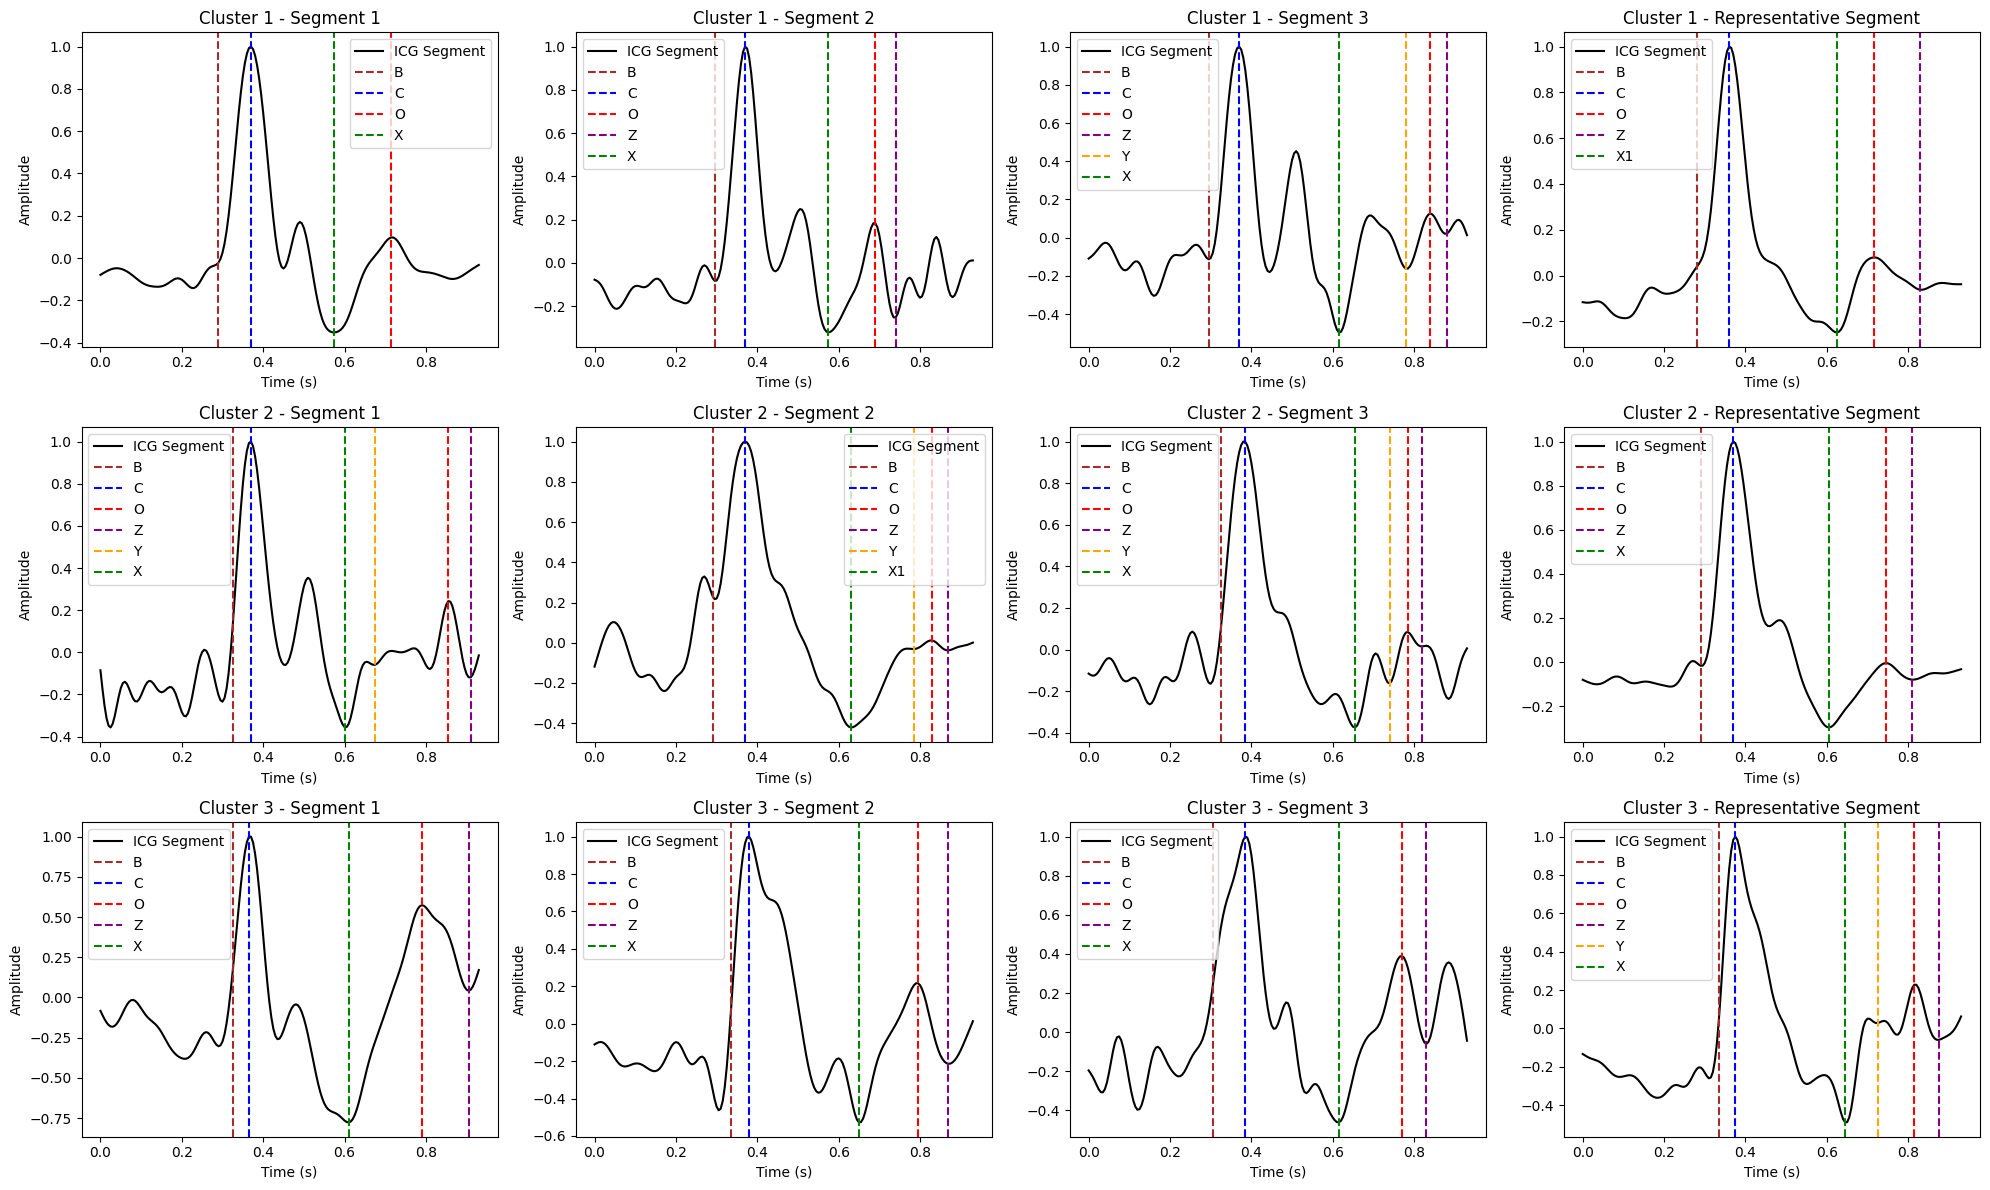

In [34]:
N = 3  # Número de segmentos a visualizar por cluster
fs = 200  # Frecuencia de muestreo

def plot_segment_with_points(ax, segment, points, fs, title=""):
    t = np.arange(len(segment)) / fs  # Vector de tiempo en segundos
    ax.plot(t, segment, label='ICG Segment', color='black')
    colors = {
        "B": "brown", "C": "blue", "X": "green", "X1": "green", "X2": "lime",
        "O": "red", "Z": "purple", "Y": "orange"
    }
    for label, index in points.items():
        if index is not None:
            ax.axvline(index / fs, color=colors.get(label, 'black'), linestyle='--', label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')


def calculate_medoid_segment(segments):
    min_len = min(len(s) for s in segments)
    trimmed_segments = [s[:min_len] for s in segments]
    n = len(trimmed_segments)

    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(trimmed_segments[i] - trimmed_segments[j])
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist

    dist_sums = dist_matrix.sum(axis=1)
    medoid_idx = np.argmin(dist_sums)

    return trimmed_segments[medoid_idx]


num_clusters = k_manual
fig, axes = plt.subplots(num_clusters, N + 1, figsize=(5 * (N + 1), 4 * num_clusters))

for cluster_id in range(num_clusters):
    # Extraer todos los segmentos del cluster actual, eliminando valores nulos
    segments = cluster_table_manual[f'Cluster_{cluster_id}'].dropna().tolist()

    if len(segments) == 0:
        print(f"⚠️ Cluster {cluster_id} vacío.")
        continue

    # Seleccionar N segmentos aleatorios
    random.seed()
    selected_segments = random.sample(segments, min(N, len(segments)))

    # Calcular el segmento representativo
    representative_segment = calculate_medoid_segment(segments)

    # Detectar puntos característicos en el segmento representativo
    C_peaks, _ = detect_C_peaks(representative_segment, fs)
    if len(C_peaks) == 0:
        print(f"⚠️ Cluster {cluster_id}: no se detectó pico C en el segmento representativo.")
        continue
    C_index = C_peaks[0]
    B_index = find_B_point(representative_segment, C_index, fs)
    resultado_X = detectar_punto_X(representative_segment, C_index, fs)
    O_index = detect_O_point(representative_segment, C_index, fs)
    Z_index = detect_Z_point(representative_segment, O_index, fs) if O_index else None
    Y_index = detectar_punto_Y(representative_segment, resultado_X, O_index, fs)

    puntos_repr = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
    if resultado_X["caso"] == "X":
        puntos_repr["X"] = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        puntos_repr["X1"] = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        puntos_repr["X1"] = resultado_X["X1"]
        puntos_repr["X2"] = resultado_X["X2"]

    # Plot de segmentos individuales
    for i, segment in enumerate(selected_segments):
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            print(f"⚠️ Segmento en Cluster {cluster_id}: sin pico C.")
            continue
        C_index = C_peaks[0]
        B_index = find_B_point(segment, C_index, fs)
        resultado_X = detectar_punto_X(segment, C_index, fs)
        O_index = detect_O_point(segment, C_index, fs)
        Z_index = detect_Z_point(segment, O_index, fs) if O_index else None
        Y_index = detectar_punto_Y(segment, resultado_X, O_index, fs)

        puntos = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
        if resultado_X["caso"] == "X":
            puntos["X"] = resultado_X["X"]
        elif resultado_X["caso"] == "X1":
            puntos["X1"] = resultado_X["X1"]
        elif resultado_X["caso"] == "X1_X2":
            puntos["X1"] = resultado_X["X1"]
            puntos["X2"] = resultado_X["X2"]

        plot_segment_with_points(axes[cluster_id, i], segment, puntos, fs, title=f"Cluster {cluster_id+1} - Segment {i+1}")

    # Plot del segmento representativo
    plot_segment_with_points(axes[cluster_id, N], representative_segment, puntos_repr, fs, title=f"Cluster {cluster_id+1} - Representative Segment")

plt.tight_layout()
plt.show()
